In [2]:
# ============================================
# CELL 1: SETUP - PHILOSOPHY BAC PREDICTOR
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix
import shap
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("=" * 60)
print("📖 PHILOSOPHY BAC PREDICTOR")
print("=" * 60)
print("✅ Libraries loaded")


📖 PHILOSOPHY BAC PREDICTOR
✅ Libraries loaded


In [21]:
# ============================================
# CELL 2: DATASET GENERATION - PHILOSOPHY (WITH CHAPTERS)
# Mean ~12, Min ~8, Fail rate ~15%, Left-skewed distribution
# 4 Methodologies + 6 Chapters + Core Skills
# ============================================

import pandas as pd
import numpy as np

np.random.seed(42)
n_students = 500

print("=" * 60)
print("GENERATING PHILOSOPHY DATASET (WITH CHAPTERS)")
print("Target: Mean ~12.0 | Min ~8 | Fail ~15% | Left-skewed")
print("4 Methodologies + 6 Chapters + Core Skills")
print("=" * 60)

# ============================================
# STEP 1: Generate BAC Score Distribution (Left-skewed)
# ============================================

bac_scores = []

# Fail students (15%) - min 8
n_fail = int(n_students * 0.15)
failing = np.random.uniform(8, 9.9, n_fail)
bac_scores.extend(failing)

# Average students (65%) - mean around 12
n_avg = int(n_students * 0.65)
average = np.random.normal(12.0, 1.8, n_avg)
average = np.clip(average, 8.5, 15.9)
bac_scores.extend(average)

# Good students (10%)
n_good = int(n_students * 0.10)
good = np.random.uniform(16, 16.9, n_good)
bac_scores.extend(good)

# Excellent students (10%)
n_excellent = int(n_students * 0.10)
excellent = np.random.uniform(17, 20, n_excellent)
bac_scores.extend(excellent)

bac_scores = np.array(bac_scores)
np.random.shuffle(bac_scores)
bac_scores = np.round(bac_scores, 1)

bac_mean = bac_scores.mean()
bac_std = bac_scores.std()
bac_scaled = (bac_scores - bac_mean) / bac_std

print(f"\n📊 BAC Score Distribution:")
print(f"   Mean: {bac_mean:.2f} (target ~12.0)")
print(f"   Std: {bac_std:.2f}")
print(f"   Min: {bac_scores.min():.1f} (target ~8)")
print(f"   Max: {bac_scores.max():.1f}")
print(f"   Fail (<10): {(bac_scores < 10).sum()} ({(bac_scores < 10).sum()/n_students*100:.1f}%)")

# Helper function
def generate_feature(bac_scaled, target_corr, target_mean, target_std):
    signal = target_corr * bac_scaled * target_std
    noise_std = target_std * np.sqrt(max(0.01, 1 - target_corr**2))
    noise = np.random.normal(0, noise_std, n_students)
    feature = target_mean + signal + noise
    return feature

# ============================================
# A. ACADEMIC HISTORY (5 features)
# ============================================

avg_grade = generate_feature(bac_scaled, 0.65, 12.0, 2.0)
avg_grade = np.clip(avg_grade, 6, 19.5).round(1)

grade_t3 = avg_grade + np.random.normal(0.3, 0.8, n_students)
grade_t3 = np.clip(grade_t3, 6, 19.5).round(1)

grade_t2 = avg_grade + np.random.normal(0, 0.9, n_students)
grade_t2 = np.clip(grade_t2, 6, 19.5).round(1)

grade_t1 = avg_grade - np.random.normal(0.5, 1.0, n_students)
grade_t1 = np.clip(grade_t1, 6, 19.5).round(1)

grade_trend = (grade_t3 - grade_t1).round(1)

print(f"\n✅ A. Academic History (5 features)")

# ============================================
# B. METHODOLOGY SKILLS (4 features)
# ============================================

dialectical_method = generate_feature(bac_scaled, 0.60, 6.0, 1.5)
dialectical_method = np.clip(dialectical_method, 2, 10).round(1)

argumentative_method = generate_feature(bac_scaled, 0.58, 6.0, 1.5)
argumentative_method = np.clip(argumentative_method, 2, 10).round(1)

comparative_method = generate_feature(bac_scaled, 0.55, 5.8, 1.6)
comparative_method = np.clip(comparative_method, 2, 10).round(1)

text_analysis_method = generate_feature(bac_scaled, 0.55, 5.8, 1.6)
text_analysis_method = np.clip(text_analysis_method, 2, 10).round(1)

print(f"✅ B. Methodology Skills (4 features)")

# ============================================
# C. CORE THINKING SKILLS (3 features)
# ============================================

conceptual_understanding = generate_feature(bac_scaled, 0.50, 6.0, 1.5)
conceptual_understanding = np.clip(conceptual_understanding, 2, 10).round(1)

logical_reasoning = generate_feature(bac_scaled, 0.60, 6.0, 1.5)
logical_reasoning = np.clip(logical_reasoning, 2, 10).round(1)

critical_thinking = generate_feature(bac_scaled, 0.55, 5.8, 1.6)
critical_thinking = np.clip(critical_thinking, 2, 10).round(1)

print(f"✅ C. Core Thinking Skills (3 features)")

# ============================================
# D. WRITING SKILLS (4 features)
# ============================================

essay_structure = generate_feature(bac_scaled, 0.50, 6.0, 1.5)
essay_structure = np.clip(essay_structure, 2, 10).round(1)

argument_strength = generate_feature(bac_scaled, 0.55, 5.8, 1.6)
argument_strength = np.clip(argument_strength, 2, 10).round(1)

clarity_expression = generate_feature(bac_scaled, 0.45, 6.0, 1.5)
clarity_expression = np.clip(clarity_expression, 2, 10).round(1)

use_of_examples = generate_feature(bac_scaled, 0.45, 5.8, 1.6)
use_of_examples = np.clip(use_of_examples, 2, 10).round(1)

print(f"✅ D. Writing Skills (4 features)")

# ============================================
# E. CHAPTER KNOWLEDGE (6 features - NEW!)
# ============================================

# 1. Problem and Problematization (المشكلة والإشكالية)
problem_chapter = generate_feature(bac_scaled, 0.45, 6.0, 1.5)
problem_chapter = np.clip(problem_chapter, 2, 10).round(1)

# 2. Philosophical Doctrines (المذاهب الفلسفية)
doctrines_chapter = generate_feature(bac_scaled, 0.50, 6.0, 1.5)
doctrines_chapter = np.clip(doctrines_chapter, 2, 10).round(1)

# 3. Philosophy of Science (فلسفة العلوم)
science_philosophy_chapter = generate_feature(bac_scaled, 0.55, 6.0, 1.5)
science_philosophy_chapter = np.clip(science_philosophy_chapter, 2, 10).round(1)

# 4. Logic (المنطق)
logic_chapter = generate_feature(bac_scaled, 0.50, 5.8, 1.6)
logic_chapter = np.clip(logic_chapter, 2, 10).round(1)

# 5. Ethics (الأخلاق)
ethics_chapter = generate_feature(bac_scaled, 0.48, 5.8, 1.6)
ethics_chapter = np.clip(ethics_chapter, 2, 10).round(1)

# 6. Society and Politics (المجتمع والسياسة)
society_politics_chapter = generate_feature(bac_scaled, 0.45, 5.5, 1.7)
society_politics_chapter = np.clip(society_politics_chapter, 2, 10).round(1)

print(f"✅ E. Chapter Knowledge (6 features)")
print(f"   problem_chapter: {np.corrcoef(bac_scores, problem_chapter)[0,1]:.3f}")
print(f"   doctrines_chapter: {np.corrcoef(bac_scores, doctrines_chapter)[0,1]:.3f}")
print(f"   science_philosophy_chapter: {np.corrcoef(bac_scores, science_philosophy_chapter)[0,1]:.3f}")

# ============================================
# F. PRACTICE (3 features)
# ============================================

essays_written_week = generate_feature(bac_scaled, 0.40, 3, 2)
essays_written_week = np.clip(essays_written_week, 0, 10).round(0).astype(int)

texts_analyzed_week = generate_feature(bac_scaled, 0.35, 3, 2)
texts_analyzed_week = np.clip(texts_analyzed_week, 0, 10).round(0).astype(int)

past_exams = generate_feature(bac_scaled, 0.35, 4, 3)
past_exams = np.clip(past_exams, 0, 15).round(0).astype(int)

print(f"✅ F. Practice (3 features)")

# ============================================
# G. STUDY BEHAVIOR (3 features)
# ============================================

study_hours = generate_feature(bac_scaled, 0.25, 4, 2)
study_hours = np.clip(study_hours, 2, 10).round(1)

consistency = generate_feature(bac_scaled, 0.25, 5, 2)
consistency = np.clip(consistency, 1, 10).round(1)

study_method = generate_feature(bac_scaled, 0.30, 5, 2)
study_method = np.clip(study_method, 1, 10).round(1)

print(f"✅ G. Study Behavior (3 features)")

# ============================================
# H. PSYCHOLOGICAL (3 features - LOW impact)
# ============================================

stress_level = generate_feature(bac_scaled, -0.08, 5.5, 2.0)
stress_level = np.clip(stress_level, 1, 10).round(1)

confidence = generate_feature(bac_scaled, 0.15, 5.0, 1.8)
confidence = np.clip(confidence, 1, 10).round(1)

interest = generate_feature(bac_scaled, 0.20, 5.0, 1.8)
interest = np.clip(interest, 1, 10).round(1)

print(f"✅ H. Psychological (3 features)")

# ============================================
# CREATE FINAL DATAFRAME
# ============================================

df = pd.DataFrame({
    # A. Academic History
    'grade_t1': grade_t1,
    'grade_t2': grade_t2,
    'grade_t3': grade_t3,
    'avg_grade': avg_grade,
    'grade_trend': grade_trend,
    
    # B. Methodology Skills
    'dialectical_method': dialectical_method,
    'argumentative_method': argumentative_method,
    'comparative_method': comparative_method,
    'text_analysis_method': text_analysis_method,
    
    # C. Core Thinking Skills
    'conceptual_understanding': conceptual_understanding,
    'logical_reasoning': logical_reasoning,
    'critical_thinking': critical_thinking,
    
    # D. Writing Skills
    'essay_structure': essay_structure,
    'argument_strength': argument_strength,
    'clarity_expression': clarity_expression,
    'use_of_examples': use_of_examples,
    
    # E. Chapter Knowledge (NEW!)
    'problem_chapter': problem_chapter,
    'doctrines_chapter': doctrines_chapter,
    'science_philosophy_chapter': science_philosophy_chapter,
    'logic_chapter': logic_chapter,
    'ethics_chapter': ethics_chapter,
    'society_politics_chapter': society_politics_chapter,
    
    # F. Practice
    'essays_written_week': essays_written_week,
    'texts_analyzed_week': texts_analyzed_week,
    'past_exams': past_exams,
    
    # G. Study Behavior
    'study_hours': study_hours,
    'consistency': consistency,
    'study_method': study_method,
    
    # H. Psychological
    'stress_level': stress_level,
    'confidence': confidence,
    'interest': interest,
    
    # TARGET
    'bac_score_philo': bac_scores
})

print("\n" + "=" * 60)
print("✅ FINAL DATASET GENERATED")
print("=" * 60)
print(f"   Students: {len(df)}")
print(f"   Features: {len(df.columns) - 1}")
print(f"   Target: bac_score_philo")

# Verification
print("\n📊 VERIFICATION - ACTUAL CORRELATIONS:")
print("-" * 55)

key_features = [
    ('avg_grade', 0.65),
    ('dialectical_method', 0.60),
    ('logical_reasoning', 0.60),
    ('argumentative_method', 0.58),
    ('argument_strength', 0.55),
    ('science_philosophy_chapter', 0.55),
    ('doctrines_chapter', 0.50),
    ('logic_chapter', 0.50),
    ('ethics_chapter', 0.48),
    ('problem_chapter', 0.45),
    ('society_politics_chapter', 0.45),
    ('essays_written_week', 0.40),
    ('past_exams', 0.35),
    ('stress_level', -0.08),
]

for feature, target in key_features:
    if feature in df.columns:
        actual = np.corrcoef(df['bac_score_philo'], df[feature])[0,1]
        status = "✅" if abs(actual - target) < 0.08 else "⚠️"
        print(f"   {feature:<30} actual: {actual:>6.3f} target: {target:>5.2f} {status}")

print("\n📊 FINAL DISTRIBUTION:")
print(f"   Mean: {df['bac_score_philo'].mean():.2f}/20 (target ~12.0)")
print(f"   Median: {df['bac_score_philo'].median():.2f}")
print(f"   Min: {df['bac_score_philo'].min():.1f} (target ~8)")
print(f"   Fail (<10): {(df['bac_score_philo'] < 10).sum()} ({(df['bac_score_philo'] < 10).sum()/n_students*100:.1f}%)")

print("\n📊 First 5 rows:")
print(df[['bac_score_philo', 'dialectical_method', 'science_philosophy_chapter', 'essays_written_week']].head())

print("\n" + "=" * 60)
print("✅ Cell 2 complete! Ready for Cell 3")
print("=" * 60)

GENERATING PHILOSOPHY DATASET (WITH CHAPTERS)
Target: Mean ~12.0 | Min ~8 | Fail ~15% | Left-skewed
4 Methodologies + 6 Chapters + Core Skills

📊 BAC Score Distribution:
   Mean: 12.76 (target ~12.0)
   Std: 2.98
   Min: 8.0 (target ~8)
   Max: 19.9
   Fail (<10): 110 (22.0%)

✅ A. Academic History (5 features)
✅ B. Methodology Skills (4 features)
✅ C. Core Thinking Skills (3 features)
✅ D. Writing Skills (4 features)
✅ E. Chapter Knowledge (6 features)
   problem_chapter: 0.443
   doctrines_chapter: 0.527
   science_philosophy_chapter: 0.540
✅ F. Practice (3 features)
✅ G. Study Behavior (3 features)
✅ H. Psychological (3 features)

✅ FINAL DATASET GENERATED
   Students: 500
   Features: 31
   Target: bac_score_philo

📊 VERIFICATION - ACTUAL CORRELATIONS:
-------------------------------------------------------
   avg_grade                      actual:  0.661 target:  0.65 ✅
   dialectical_method             actual:  0.574 target:  0.60 ✅
   logical_reasoning              actual:  0.59

In [22]:
# ============================================
# CELL 3: SAVE DATASET
# ============================================

df.to_csv("philosophy_bac_dataset.csv", index=False)

print("✅ Dataset saved: philosophy_bac_dataset.csv")
print(f"📊 Shape: {df.shape}")
print(f"🎯 BAC Score mean: {df['bac_score_philo'].mean():.2f}/20")
print(f"📈 BAC Score range: {df['bac_score_philo'].min():.1f} - {df['bac_score_philo'].max():.1f}")

✅ Dataset saved: philosophy_bac_dataset.csv
📊 Shape: (500, 32)
🎯 BAC Score mean: 12.76/20
📈 BAC Score range: 8.0 - 19.9


In [23]:
# ============================================
# CELL 4: LOAD DATASET
# ============================================

df = pd.read_csv("philosophy_bac_dataset.csv")

print("✅ Dataset loaded: philosophy_bac_dataset.csv")
print(f"📊 Shape: {df.shape}")
print(f"🎯 BAC Score mean: {df['bac_score_philo'].mean():.2f}/20")
print(f"📈 BAC Score range: {df['bac_score_philo'].min():.1f} - {df['bac_score_philo'].max():.1f}")

✅ Dataset loaded: philosophy_bac_dataset.csv
📊 Shape: (500, 32)
🎯 BAC Score mean: 12.76/20
📈 BAC Score range: 8.0 - 19.9


In [24]:
# ============================================
# CELL 5: EDA - OVERVIEW
# ============================================

print("=" * 60)
print("📊 EXPLORATORY DATA ANALYSIS - PHILOSOPHY")
print("=" * 60)

print("\n1️⃣ FIRST 5 ROWS:")
print(df.head())

print("\n2️⃣ LAST 5 ROWS:")
print(df.tail())

print("\n3️⃣ DATASET INFO:")
print(df.info())

print("\n4️⃣ BASIC STATISTICS:")
print(df.describe().round(2))

print("\n5️⃣ MISSING VALUES:")
print(f"   Missing values: {df.isnull().sum().sum()}")
print("   ✅ No missing values")

print("\n6️⃣ DATASET SHAPE:")
print(f"   Rows: {df.shape[0]}")
print(f"   Columns: {df.shape[1]}")
print(f"   Features: {df.shape[1] - 1}")
print(f"   Target: 1 (bac_score_philo)")

print("\n7️⃣ DATA TYPES:")
print(df.dtypes.value_counts())

print("\n✅ Cell 5 complete! Ready for Cell 6")

📊 EXPLORATORY DATA ANALYSIS - PHILOSOPHY

1️⃣ FIRST 5 ROWS:
   grade_t1  grade_t2  grade_t3  avg_grade  grade_trend  dialectical_method  \
0      10.7      10.4      13.5       11.9          2.8                 4.3   
1      12.2      11.8      14.3       12.7          2.1                 5.8   
2      13.9      12.4      13.3       13.4         -0.6                 6.4   
3      13.8      14.8      14.7       13.9          0.9                 7.4   
4      11.3      14.0      14.1       12.5          2.8                 6.3   

   argumentative_method  comparative_method  text_analysis_method  \
0                   5.2                 4.6                   3.2   
1                   7.4                 5.4                   7.9   
2                   4.4                 5.5                   5.3   
3                   5.8                 4.9                   7.3   
4                   6.5                 3.3                   5.0   

   conceptual_understanding  logical_reasoning  cr

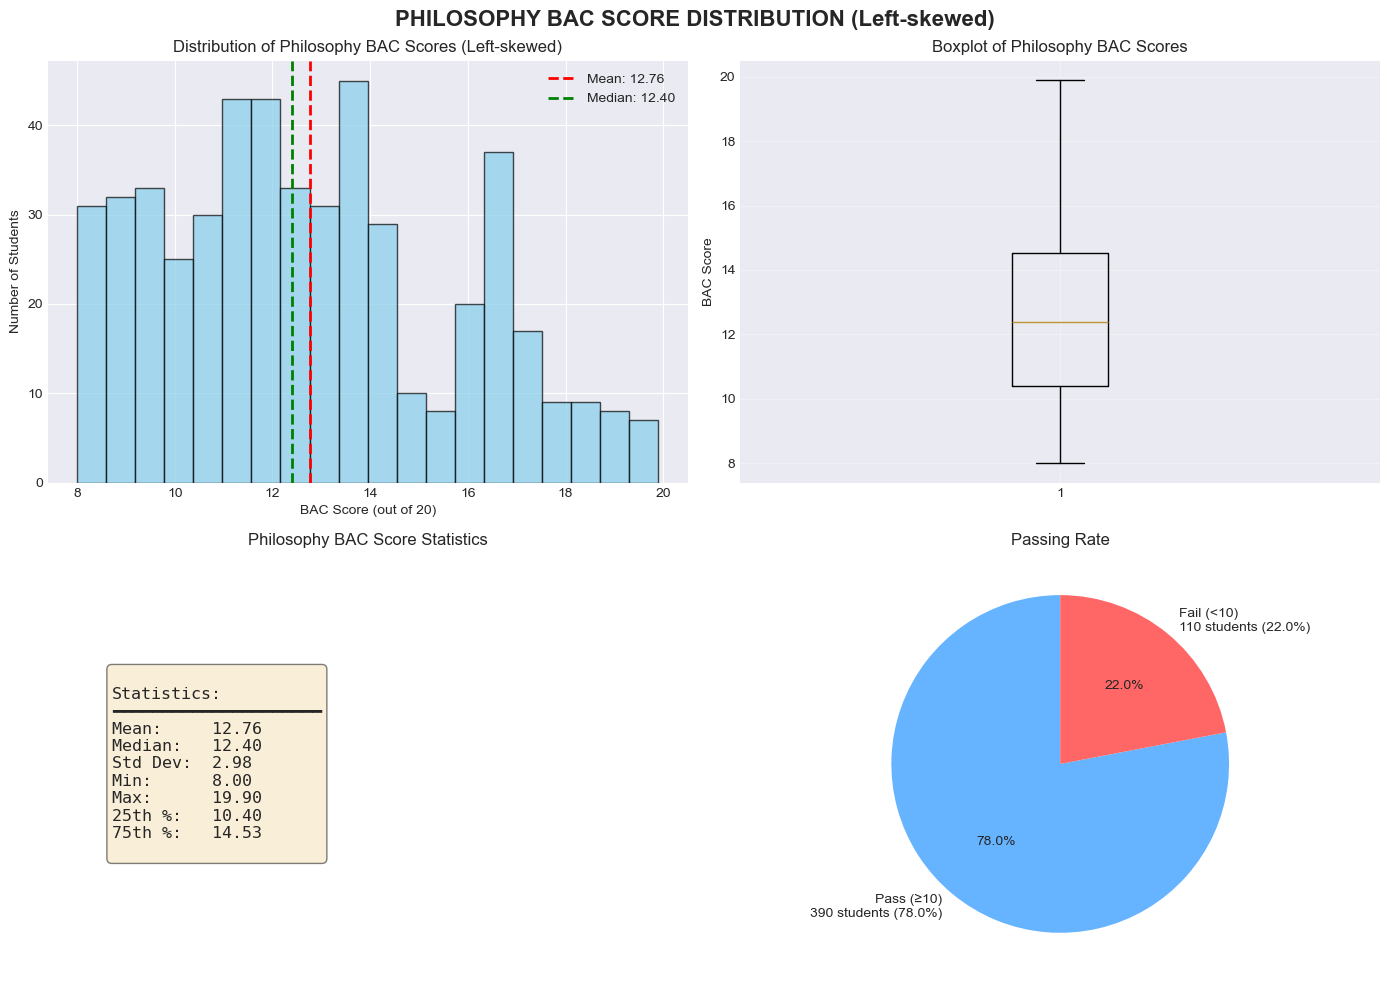


📊 DISTRIBUTION SUMMARY
   Mean:     12.76/20
   Median:   12.40/20
   Std Dev:  2.98
   Pass Rate: 78.0% (390/500)
   Fail Rate: 22.0% (110/500)
💡 Note: Lower mean (~11) because Philosophy is studied only in BAC year

✅ Cell 6 complete! Ready for Cell 7


In [12]:
# ============================================
# CELL 6: EDA - BAC DISTRIBUTION
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram
axes[0,0].hist(df['bac_score_philo'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[0,0].axvline(df['bac_score_philo'].mean(), color='red', linestyle='dashed', linewidth=2, 
                  label=f'Mean: {df["bac_score_philo"].mean():.2f}')
axes[0,0].axvline(df['bac_score_philo'].median(), color='green', linestyle='dashed', linewidth=2, 
                  label=f'Median: {df["bac_score_philo"].median():.2f}')
axes[0,0].set_xlabel('BAC Score (out of 20)')
axes[0,0].set_ylabel('Number of Students')
axes[0,0].set_title('Distribution of Philosophy BAC Scores (Left-skewed)')
axes[0,0].legend()

# 2. Boxplot
axes[0,1].boxplot(df['bac_score_philo'], vert=True)
axes[0,1].set_ylabel('BAC Score')
axes[0,1].set_title('Boxplot of Philosophy BAC Scores')
axes[0,1].grid(True, alpha=0.3)

# 3. Statistics table
stats_text = f"""
Statistics:
━━━━━━━━━━━━━━━━━━━━━
Mean:     {df['bac_score_philo'].mean():.2f}
Median:   {df['bac_score_philo'].median():.2f}
Std Dev:  {df['bac_score_philo'].std():.2f}
Min:      {df['bac_score_philo'].min():.2f}
Max:      {df['bac_score_philo'].max():.2f}
25th %:   {df['bac_score_philo'].quantile(0.25):.2f}
75th %:   {df['bac_score_philo'].quantile(0.75):.2f}
"""
axes[1,0].text(0.1, 0.5, stats_text, fontsize=12, verticalalignment='center', 
               fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1,0].axis('off')
axes[1,0].set_title('Philosophy BAC Score Statistics')

# 4. Passing rate pie chart
passing = (df['bac_score_philo'] >= 10).sum()
failing = len(df) - passing
colors_pie = ['#66b3ff', '#ff6666']
labels = [f'Pass (≥10)\n{passing} students ({passing/len(df)*100:.1f}%)', 
          f'Fail (<10)\n{failing} students ({failing/len(df)*100:.1f}%)']
axes[1,1].pie([passing, failing], labels=labels, colors=colors_pie, autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Passing Rate')

plt.suptitle('PHILOSOPHY BAC SCORE DISTRIBUTION (Left-skewed)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("📊 DISTRIBUTION SUMMARY")
print("=" * 60)
print(f"   Mean:     {df['bac_score_philo'].mean():.2f}/20")
print(f"   Median:   {df['bac_score_philo'].median():.2f}/20")
print(f"   Std Dev:  {df['bac_score_philo'].std():.2f}")
print(f"   Pass Rate: {passing/len(df)*100:.1f}% ({passing}/{len(df)})")
print(f"   Fail Rate: {failing/len(df)*100:.1f}% ({failing}/{len(df)})")
print("=" * 60)
print("💡 Note: Lower mean (~11) because Philosophy is studied only in BAC year")
print("=" * 60)

print("\n✅ Cell 6 complete! Ready for Cell 7")


📊 CORRELATION WITH BAC SCORE (highest to lowest):
   bac_score_philo               : 1.000
   avg_grade                     : 0.661
   grade_t2                      : 0.627
   grade_t3                      : 0.608
   logical_reasoning             : 0.598
   argumentative_method          : 0.587
   grade_t1                      : 0.583
   dialectical_method            : 0.574
   comparative_method            : 0.572
   text_analysis_method          : 0.562
   logic_chapter                 : 0.554
   science_philosophy_chapter    : 0.540
   argument_strength             : 0.535
   essay_structure               : 0.530
   doctrines_chapter             : 0.527
   conceptual_understanding      : 0.523
   critical_thinking             : 0.523
   ethics_chapter                : 0.459
   problem_chapter               : 0.443
   society_politics_chapter      : 0.429


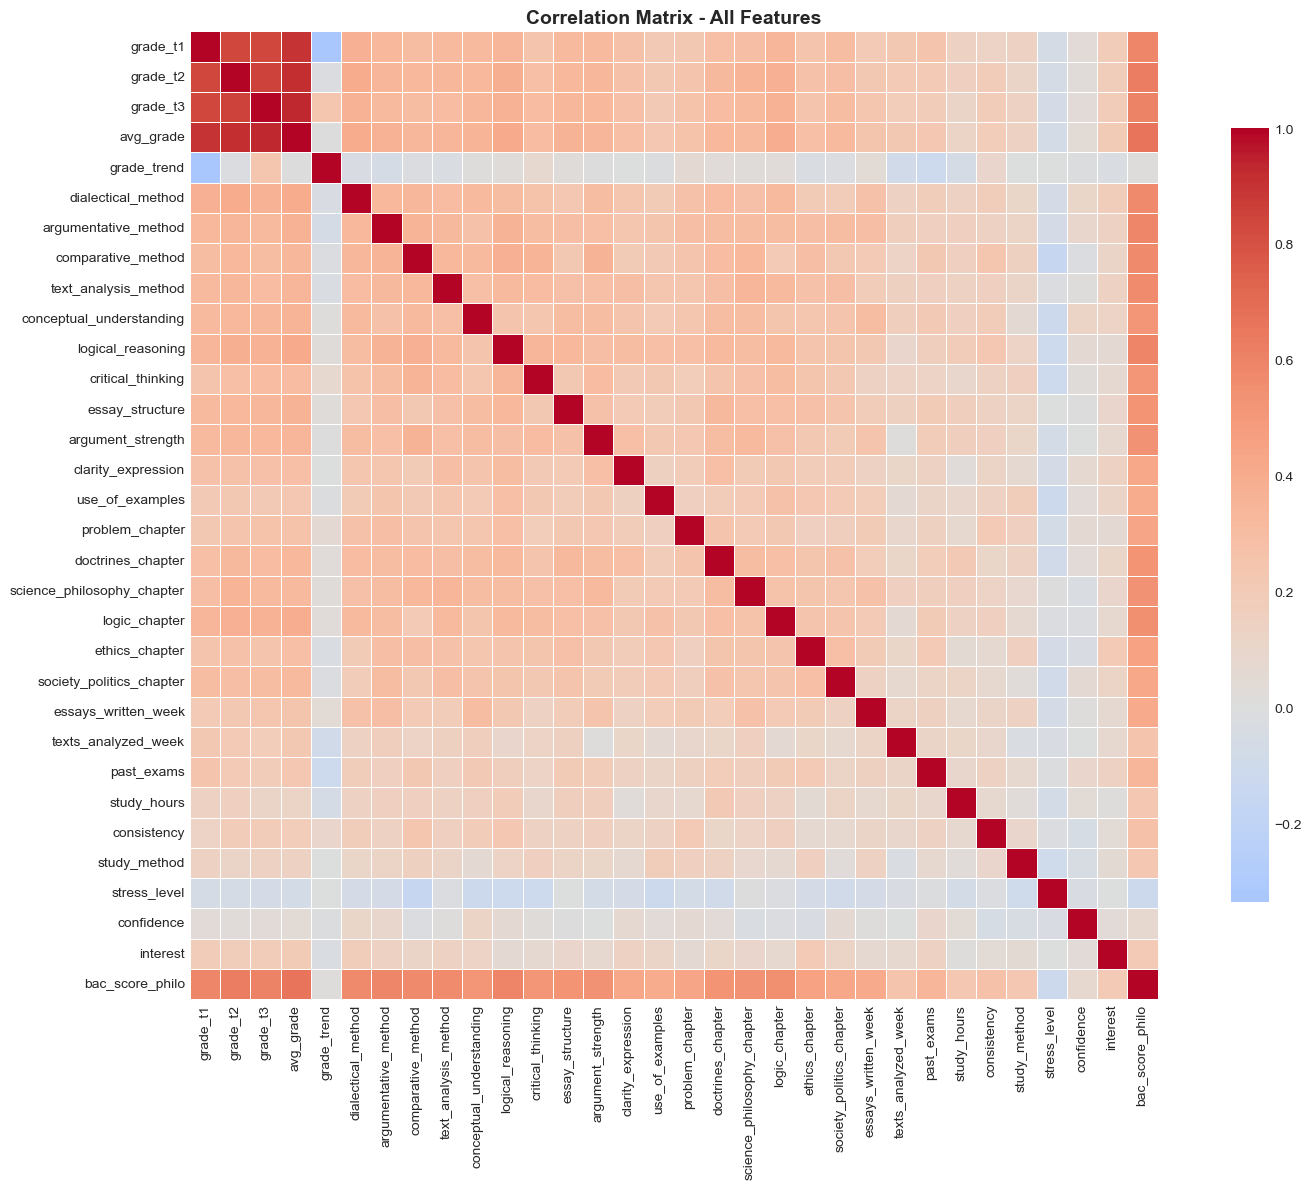

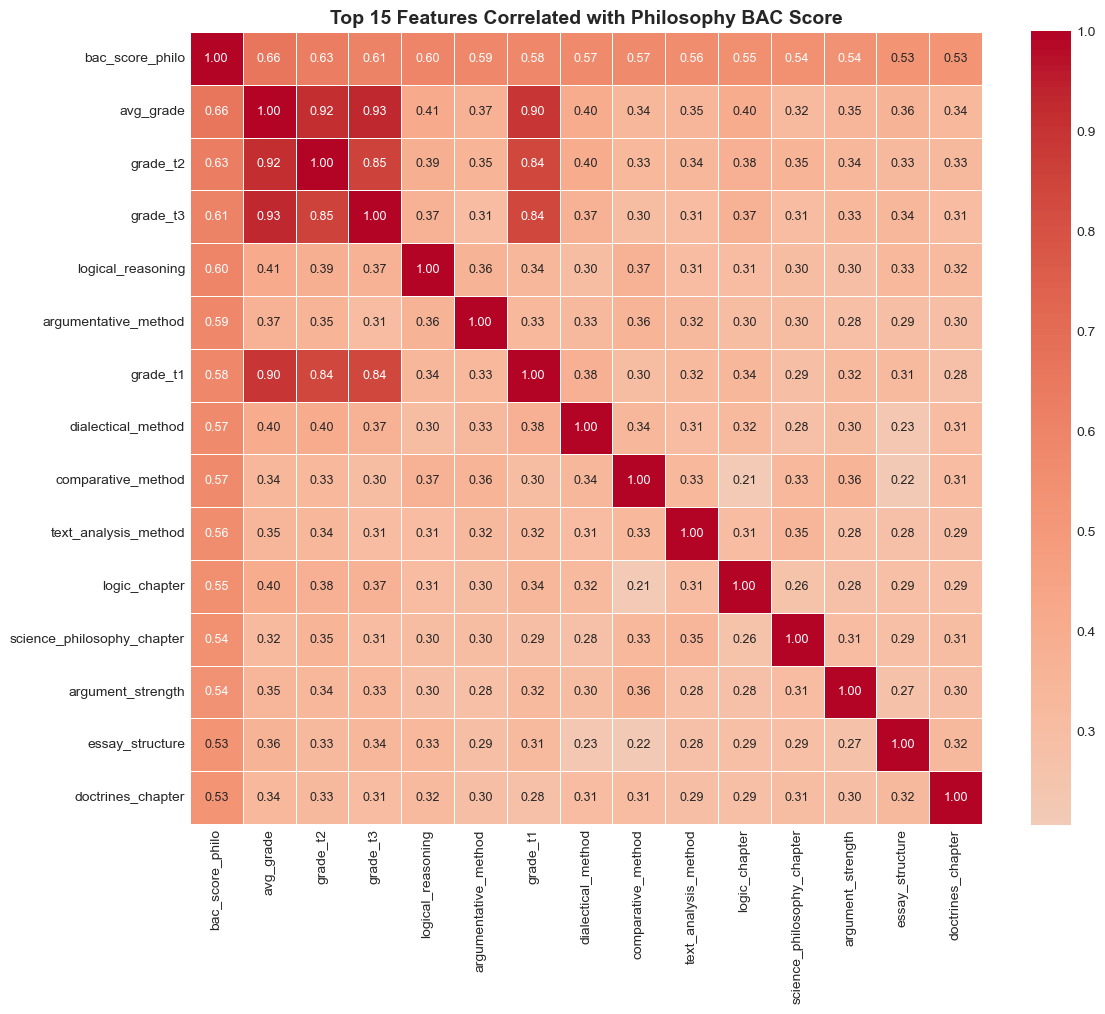

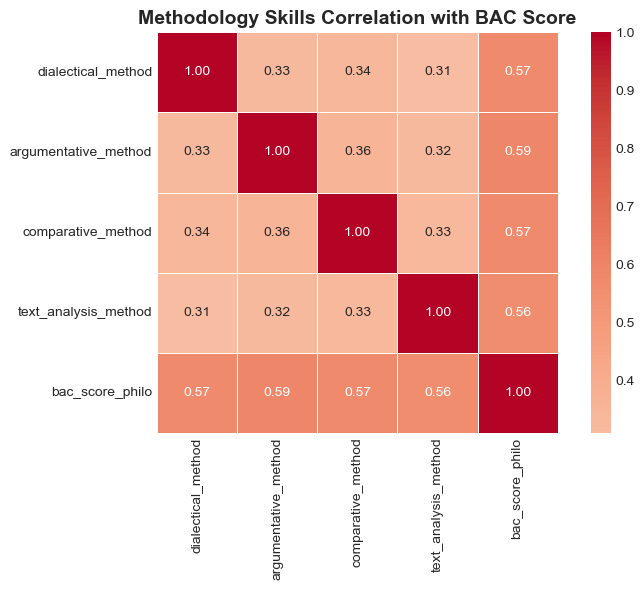

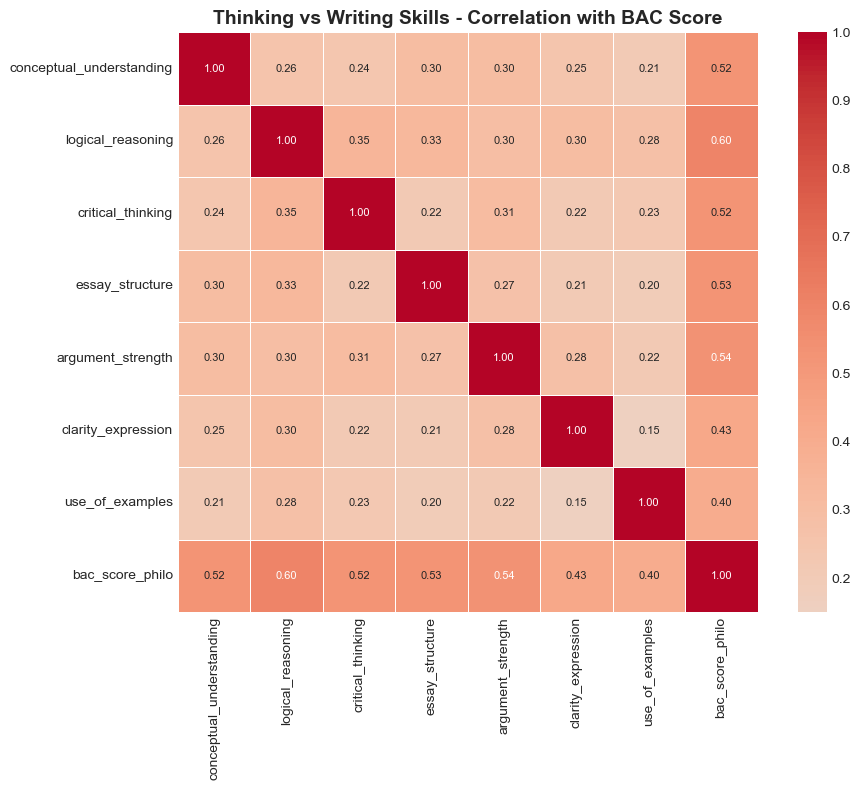


📊 KEY INSIGHTS:
   Methodology skills avg correlation: 0.574
   Thinking skills avg correlation: 0.548
   Writing skills avg correlation: 0.474

✅ Cell 7 complete! Ready for Cell 8


In [25]:
# ============================================
# CELL 7: EDA - CORRELATION HEATMAPS
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Correlation with target
corr_matrix = df.corr()
bac_corr = corr_matrix['bac_score_philo'].sort_values(ascending=False)

print("\n📊 CORRELATION WITH BAC SCORE (highest to lowest):")
print("=" * 55)
for feature, corr_value in bac_corr.head(20).items():
    print(f"   {feature:30s}: {corr_value:.3f}")

# Heatmap 1: All features
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - All Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Heatmap 2: Top features only
top_features = bac_corr.head(15).index.tolist()
plt.figure(figsize=(12, 10))
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', linewidths=0.5, annot_kws={'size': 9})
plt.title('Top 15 Features Correlated with Philosophy BAC Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Heatmap 3: Methodology skills comparison
method_cols = ['dialectical_method', 'argumentative_method', 'comparative_method', 'text_analysis_method']
plt.figure(figsize=(8, 6))
sns.heatmap(df[method_cols + ['bac_score_philo']].corr(), annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', linewidths=0.5, annot_kws={'size': 10})
plt.title('Methodology Skills Correlation with BAC Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Heatmap 4: Thinking vs Writing comparison
thinking_cols = ['conceptual_understanding', 'logical_reasoning', 'critical_thinking']
writing_cols = ['essay_structure', 'argument_strength', 'clarity_expression', 'use_of_examples']
compare_cols = thinking_cols + writing_cols + ['bac_score_philo']

plt.figure(figsize=(10, 8))
sns.heatmap(df[compare_cols].corr(), annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', linewidths=0.5, annot_kws={'size': 8})
plt.title('Thinking vs Writing Skills - Correlation with BAC Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 KEY INSIGHTS:")
print(f"   Methodology skills avg correlation: {df[method_cols].corrwith(df['bac_score_philo']).mean():.3f}")
print(f"   Thinking skills avg correlation: {df[thinking_cols].corrwith(df['bac_score_philo']).mean():.3f}")
print(f"   Writing skills avg correlation: {df[writing_cols].corrwith(df['bac_score_philo']).mean():.3f}")
print("=" * 55)

print("\n✅ Cell 7 complete! Ready for Cell 8")

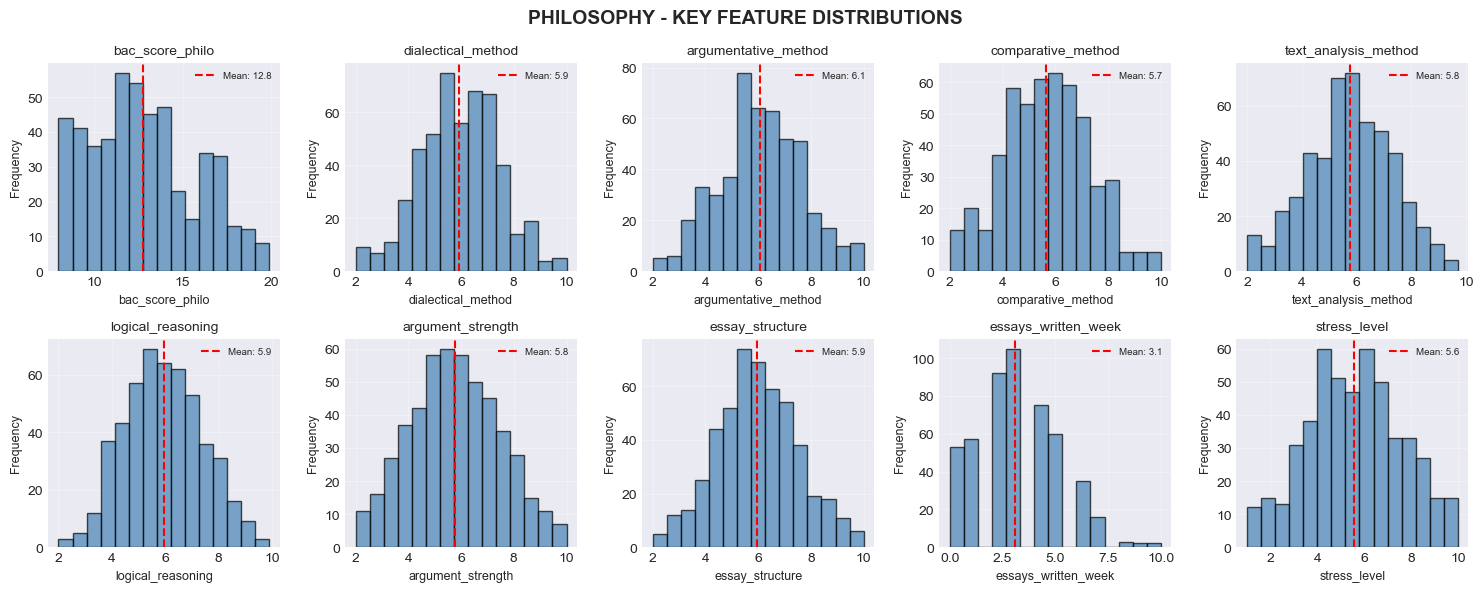


📊 METHODOLOGY SKILLS:
       dialectical_method  argumentative_method  comparative_method  \
count              500.00                500.00              500.00   
mean                 5.92                  6.08                5.66   
std                  1.48                  1.58                1.61   
min                  2.00                  2.00                2.00   
25%                  4.90                  5.10                4.50   
50%                  5.95                  6.10                5.70   
75%                  6.90                  7.10                6.70   
max                 10.00                 10.00               10.00   

       text_analysis_method  
count                500.00  
mean                   5.75  
std                    1.56  
min                    2.00  
25%                    4.70  
50%                    5.70  
75%                    6.90  
max                    9.70  

📊 THINKING SKILLS:
       conceptual_understanding  logical_reason

In [26]:
# ============================================
# CELL 8: EDA - FEATURE DISTRIBUTIONS (FIXED)
# ============================================

import matplotlib.pyplot as plt

# Key features to visualize (reduced to 10)
key_features = ['bac_score_philo', 'dialectical_method', 'argumentative_method', 
                'comparative_method', 'text_analysis_method', 'logical_reasoning',
                'argument_strength', 'essay_structure', 'essays_written_week', 'stress_level']

# Filter available features
available_features = [f for f in key_features if f in df.columns]

# Calculate grid size (2 rows x 5 columns = 10)
n_features = len(available_features)
n_cols = 5
n_rows = 2

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 6))
axes = axes.flatten()

for i, feature in enumerate(available_features):
    axes[i].hist(df[feature], bins=15, edgecolor='black', color='steelblue', alpha=0.7)
    axes[i].axvline(df[feature].mean(), color='red', linestyle='dashed', linewidth=1.5, 
                    label=f'Mean: {df[feature].mean():.1f}')
    axes[i].set_xlabel(feature, fontsize=9)
    axes[i].set_ylabel('Frequency', fontsize=9)
    axes[i].set_title(f'{feature}', fontsize=10)
    axes[i].legend(fontsize=7)
    axes[i].grid(True, alpha=0.3)

# Hide unused subplots
for i in range(len(available_features), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('PHILOSOPHY - KEY FEATURE DISTRIBUTIONS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary stats
print("\n📊 METHODOLOGY SKILLS:")
method_cols = ['dialectical_method', 'argumentative_method', 'comparative_method', 'text_analysis_method']
print(df[method_cols].describe().round(2))

print("\n📊 THINKING SKILLS:")
thinking_cols = ['conceptual_understanding', 'logical_reasoning', 'critical_thinking']
print(df[thinking_cols].describe().round(2))

print("\n📊 WRITING SKILLS:")
writing_cols = ['essay_structure', 'argument_strength', 'clarity_expression', 'use_of_examples']
print(df[writing_cols].describe().round(2))

print("\n📊 PRACTICE HABITS:")
practice_cols = ['essays_written_week', 'texts_analyzed_week', 'past_exams']
print(df[practice_cols].describe().round(2))

print("\n✅ Cell 8 complete! Ready for Cell 9")

In [17]:
# ============================================
# CELL 9: FEATURE ENGINEERING - PHILOSOPHY 
# ============================================

print("=" * 40)
print("FEATURE ENGINEERING")
print("=" * 40)

# Create a copy
df_fe = df.copy()

# 1. Methodology composite (average of 4 methodology skills)
method_cols = ['dialectical_method', 'argumentative_method', 'comparative_method', 'text_analysis_method']
df_fe['methodology_composite'] = df_fe[method_cols].mean(axis=1).round(1)

# 2. Thinking composite (average of thinking skills)
thinking_cols = ['conceptual_understanding', 'logical_reasoning', 'critical_thinking']
df_fe['thinking_composite'] = df_fe[thinking_cols].mean(axis=1).round(1)

# 3. Writing composite (average of writing skills)
writing_cols = ['essay_structure', 'argument_strength', 'clarity_expression', 'use_of_examples']
df_fe['writing_composite'] = df_fe[writing_cols].mean(axis=1).round(1)

# 4. Knowledge composite (average of content knowledge)
knowledge_cols = ['philosophy_knowledge', 'philosopher_knowledge', 'concept_mastery']
df_fe['knowledge_composite'] = df_fe[knowledge_cols].mean(axis=1).round(1)

# 5. Practice intensity (weighted average of practice features)
df_fe['practice_intensity'] = (
    df_fe['essays_written_week'] / 10 * 10 * 0.4 +
    df_fe['texts_analyzed_week'] / 10 * 10 * 0.3 +
    df_fe['past_exams'] / 15 * 10 * 0.3
).round(1)

# 6. Study quality
df_fe['study_quality'] = (df_fe['consistency'] * 0.6 + 
                          df_fe['study_method'] * 0.4).round(1)

# 7. Imbalance score (variance between methodology, thinking, writing)
df_fe['philo_imbalance'] = df_fe[['methodology_composite', 'thinking_composite', 'writing_composite']].var(axis=1).round(2)

# 8. Overall philosophy level
df_fe['overall_philo'] = (df_fe['methodology_composite'] + df_fe['thinking_composite'] + 
                          df_fe['writing_composite'] + df_fe['knowledge_composite']) / 4
df_fe['overall_philo'] = df_fe['overall_philo'].round(1)

print("\n✅ New features created:")
print("   • methodology_composite (0-10) - avg of 4 BAC methodologies")
print("   • thinking_composite (0-10) - avg of thinking skills")
print("   • writing_composite (0-10) - avg of writing skills")
print("   • knowledge_composite (0-10) - avg of content knowledge")
print("   • practice_intensity (0-10)")
print("   • study_quality (0-10)")
print("   • philo_imbalance (variance between methodology, thinking, writing)")
print("   • overall_philo (0-10)")

# Update dataframe
df = df_fe.copy()

print(f"\n📊 Total columns now: {df.shape[1]}")
print("✅ Cell 9 complete! Ready for Cell 10")

FEATURE ENGINEERING

✅ New features created:
   • methodology_composite (0-10) - avg of 4 BAC methodologies
   • thinking_composite (0-10) - avg of thinking skills
   • writing_composite (0-10) - avg of writing skills
   • knowledge_composite (0-10) - avg of content knowledge
   • practice_intensity (0-10)
   • study_quality (0-10)
   • philo_imbalance (variance between methodology, thinking, writing)
   • overall_philo (0-10)

📊 Total columns now: 37
✅ Cell 9 complete! Ready for Cell 10


In [27]:
# ============================================
# CELL 10: TRAIN/TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

print("=" * 40)
print("TRAIN/TEST SPLIT")
print("=" * 40)

# Define features (X) and target (y)
X = df.drop('bac_score_philo', axis=1)
y = df['bac_score_philo']

print(f"\n📊 Features (X): {X.shape[1]} columns")
print(f"📊 Target (y): bac_score_philo")

# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n✅ Split complete:")
print(f"   Training set: {X_train.shape[0]} students ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"   Test set:     {X_test.shape[0]} students ({X_test.shape[0]/len(df)*100:.0f}%)")

print("\n✅ Cell 10 complete! Ready for Cell 11")

TRAIN/TEST SPLIT

📊 Features (X): 31 columns
📊 Target (y): bac_score_philo

✅ Split complete:
   Training set: 400 students (80%)
   Test set:     100 students (20%)

✅ Cell 10 complete! Ready for Cell 11


In [28]:
# ============================================
# CELL 11: MODEL TRAINING - PHILOSOPHY
# ============================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("=" * 40)
print("MODEL TRAINING - PHILOSOPHY")
print("=" * 40)

# Train Random Forest
print(f"\n🚀 Training Random Forest Regressor...")

model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print(f"✅ Model training complete")

# Predictions
y_pred = model.predict(X_test)

# Evaluate
print("\n" + "=" * 40)
print("MODEL EVALUATION")
print("=" * 40)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n📊 Performance Metrics:")
print(f"   MAE:  {mae:.2f} points")
print(f"   RMSE: {rmse:.2f} points")
print(f"   R²:   {r2:.3f}")

# Feature Importance
print("\n" + "=" * 40)
print("FEATURE IMPORTANCE")
print("=" * 40)

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 most important features:")
for i, row in feature_importance.head(15).iterrows():
    print(f"   {row['feature']:30s}: {row['importance']:.4f}")

print("\n✅ Cell 11 complete! Ready for Cell 12")

MODEL TRAINING - PHILOSOPHY

🚀 Training Random Forest Regressor...
✅ Model training complete

MODEL EVALUATION

📊 Performance Metrics:
   MAE:  1.15 points
   RMSE: 1.42 points
   R²:   0.793

FEATURE IMPORTANCE

Top 15 most important features:
   avg_grade                     : 0.1466
   dialectical_method            : 0.0877
   logical_reasoning             : 0.0857
   text_analysis_method          : 0.0797
   grade_t2                      : 0.0796
   comparative_method            : 0.0739
   doctrines_chapter             : 0.0574
   essay_structure               : 0.0424
   conceptual_understanding      : 0.0406
   logic_chapter                 : 0.0395
   argumentative_method          : 0.0369
   argument_strength             : 0.0351
   science_philosophy_chapter    : 0.0253
   critical_thinking             : 0.0221
   ethics_chapter                : 0.0172

✅ Cell 11 complete! Ready for Cell 12


MODEL EVALUATION (DETAILED) - PHILOSOPHY

----------------------------------------
1. SCORE PREDICTION (0-20)
----------------------------------------
   Mean Absolute Error (MAE):     1.150 points
   Root Mean Squared Error (RMSE): 1.421 points
   R² Score:                      0.793

----------------------------------------
2. PASS/FAIL CLASSIFICATION (≥10/20)
----------------------------------------
   Accuracy: 0.790 (79.0%)

   Confusion Matrix:
   True Negatives (correct fail):  6
   False Positives:                21
   False Negatives:                0
   True Positives (correct pass):  73


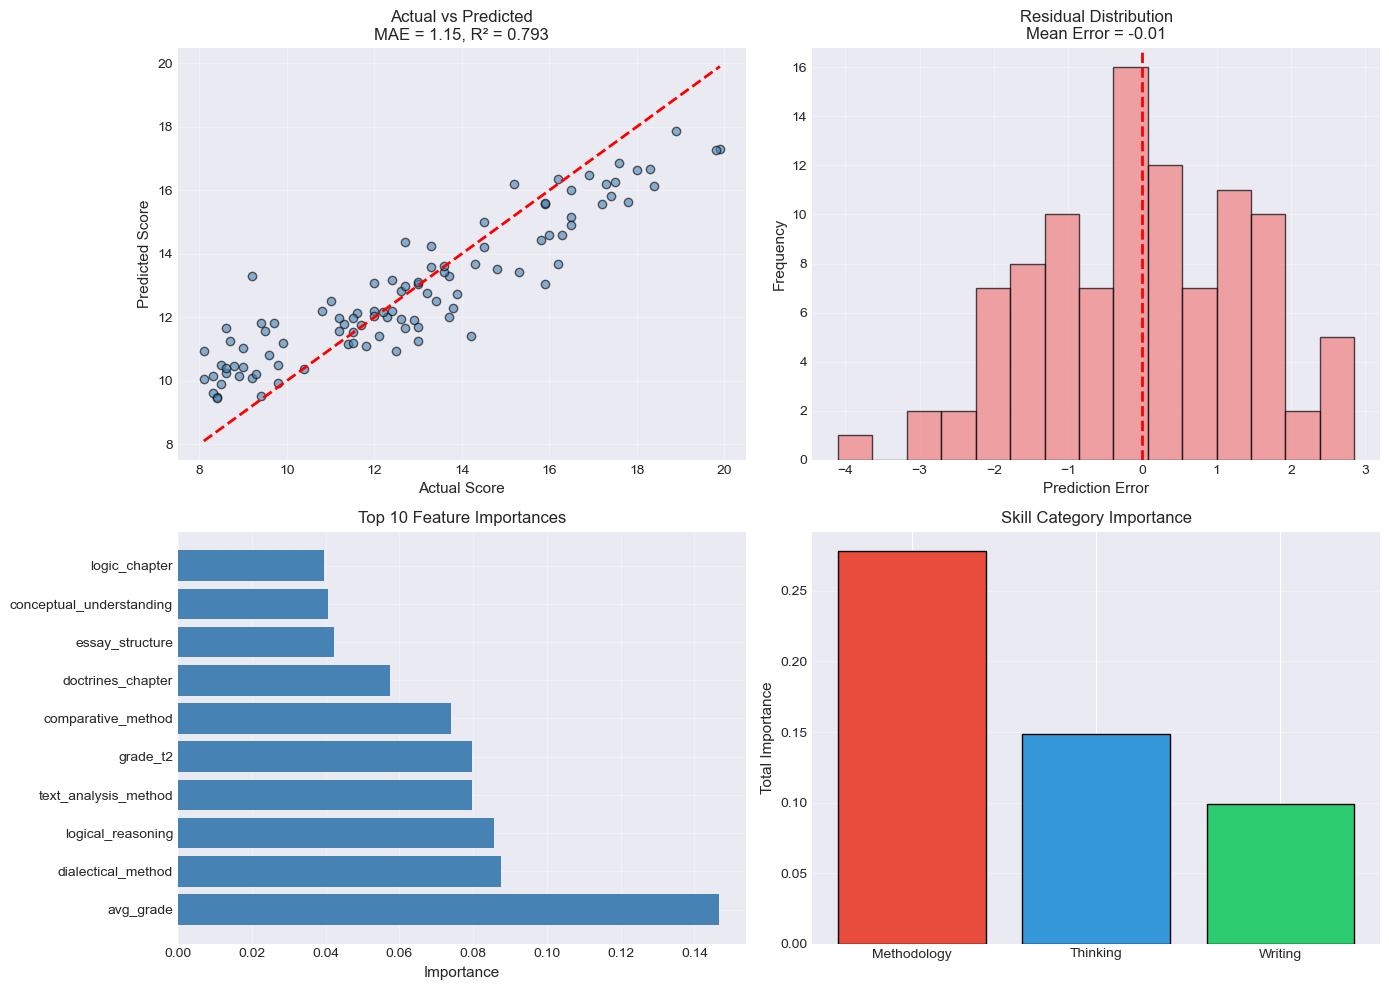


----------------------------------------
3. ERROR SUMMARY
----------------------------------------
   Mean Error:      1.150 points
   Median Error:    1.070 points
   Error < 1 point: 46.0% of predictions
   Error < 2 points: 85.0% of predictions

✅ Evaluation Complete


In [29]:
# ============================================
# CELL 12: MODEL EVALUATION (DETAILED) - PHILOSOPHY
# ============================================

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

print("=" * 50)
print("MODEL EVALUATION (DETAILED) - PHILOSOPHY")
print("=" * 50)

# 1. Score Prediction Metrics
print("\n" + "-" * 40)
print("1. SCORE PREDICTION (0-20)")
print("-" * 40)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"   Mean Absolute Error (MAE):     {mae:.3f} points")
print(f"   Root Mean Squared Error (RMSE): {rmse:.3f} points")
print(f"   R² Score:                      {r2:.3f}")

# 2. Pass/Fail Classification
print("\n" + "-" * 40)
print("2. PASS/FAIL CLASSIFICATION (≥10/20)")
print("-" * 40)

y_true_class = (y_test >= 10).astype(int)
y_pred_class = (y_pred >= 10).astype(int)

accuracy = accuracy_score(y_true_class, y_pred_class)
print(f"   Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")

print("\n   Confusion Matrix:")
cm = confusion_matrix(y_true_class, y_pred_class)
print(f"   True Negatives (correct fail):  {cm[0][0]}")
print(f"   False Positives:                {cm[0][1]}")
print(f"   False Negatives:                {cm[1][0]}")
print(f"   True Positives (correct pass):  {cm[1][1]}")

# 3. Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Actual vs Predicted
axes[0,0].scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='black')
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0,0].set_xlabel('Actual Score', fontsize=11)
axes[0,0].set_ylabel('Predicted Score', fontsize=11)
axes[0,0].set_title(f'Actual vs Predicted\nMAE = {mae:.2f}, R² = {r2:.3f}', fontsize=12)
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals = y_test - y_pred
axes[0,1].hist(residuals, bins=15, edgecolor='black', color='lightcoral', alpha=0.7)
axes[0,1].axvline(0, color='red', linestyle='dashed', linewidth=2)
axes[0,1].set_xlabel('Prediction Error', fontsize=11)
axes[0,1].set_ylabel('Frequency', fontsize=11)
axes[0,1].set_title(f'Residual Distribution\nMean Error = {residuals.mean():.2f}', fontsize=12)
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Feature Importance (Top 10)
top_features = feature_importance.head(10)
axes[1,0].barh(top_features['feature'], top_features['importance'], color='steelblue')
axes[1,0].set_xlabel('Importance', fontsize=11)
axes[1,0].set_title('Top 10 Feature Importances', fontsize=12)
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Methodology vs Thinking vs Writing importance
method_imp = feature_importance[feature_importance['feature'].isin(['dialectical_method', 'argumentative_method', 'comparative_method', 'text_analysis_method', 'methodology_composite'])]['importance'].sum()
thinking_imp = feature_importance[feature_importance['feature'].isin(['logical_reasoning', 'conceptual_understanding', 'critical_thinking', 'thinking_composite'])]['importance'].sum()
writing_imp = feature_importance[feature_importance['feature'].isin(['essay_structure', 'argument_strength', 'clarity_expression', 'use_of_examples', 'writing_composite'])]['importance'].sum()

categories = ['Methodology', 'Thinking', 'Writing']
values = [method_imp, thinking_imp, writing_imp]
colors_bar = ['#e74c3c', '#3498db', '#2ecc71']
axes[1,1].bar(categories, values, color=colors_bar, edgecolor='black')
axes[1,1].set_ylabel('Total Importance', fontsize=11)
axes[1,1].set_title('Skill Category Importance', fontsize=12)
axes[1,1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 4. Error Summary
print("\n" + "-" * 40)
print("3. ERROR SUMMARY")
print("-" * 40)

errors = np.abs(y_test - y_pred)
print(f"   Mean Error:      {errors.mean():.3f} points")
print(f"   Median Error:    {errors.median():.3f} points")
print(f"   Error < 1 point: {(errors < 1).mean()*100:.1f}% of predictions")
print(f"   Error < 2 points: {(errors < 2).mean()*100:.1f}% of predictions")

print("\n" + "=" * 50)
print("✅ Evaluation Complete")
print("=" * 50)

SHAP EXPLAINABILITY - PHILOSOPHY

📊 Creating SHAP explainer...
✅ SHAP explainer created
   SHAP values shape: (100, 31)


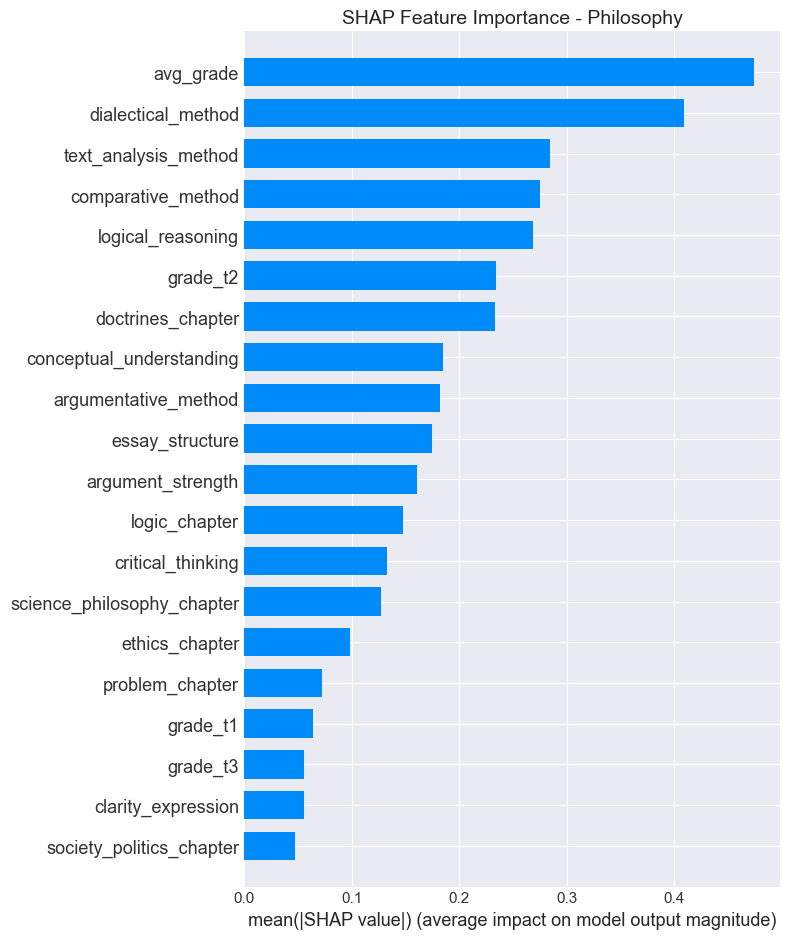

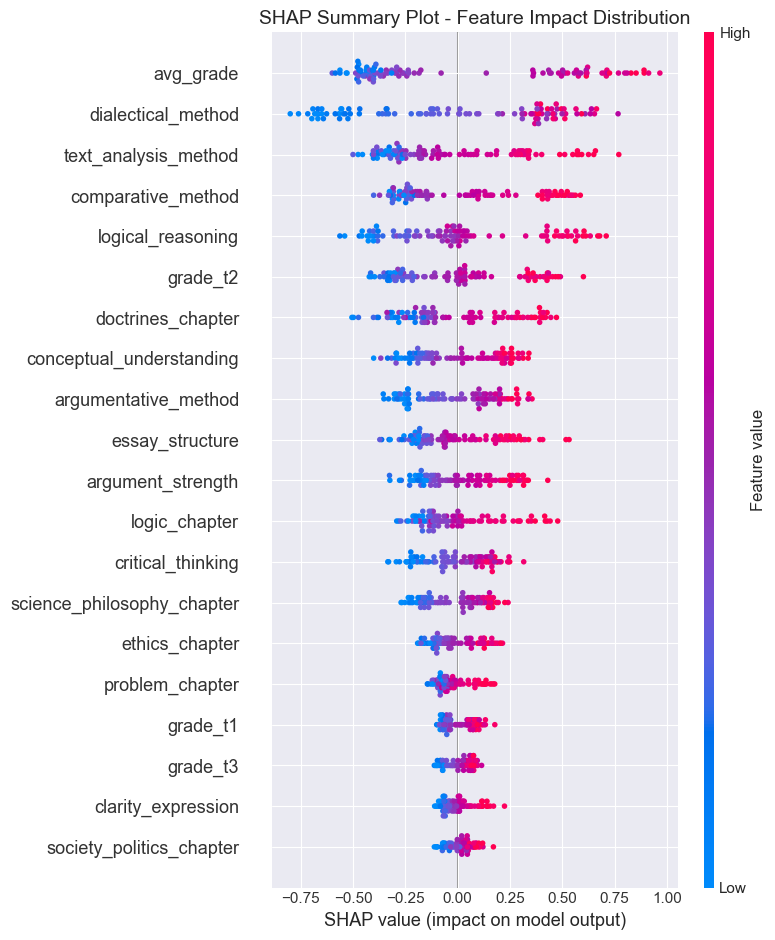


SINGLE STUDENT EXPLANATION

📊 Student #0:
   Actual score: 15.9
   Predicted score: 15.6


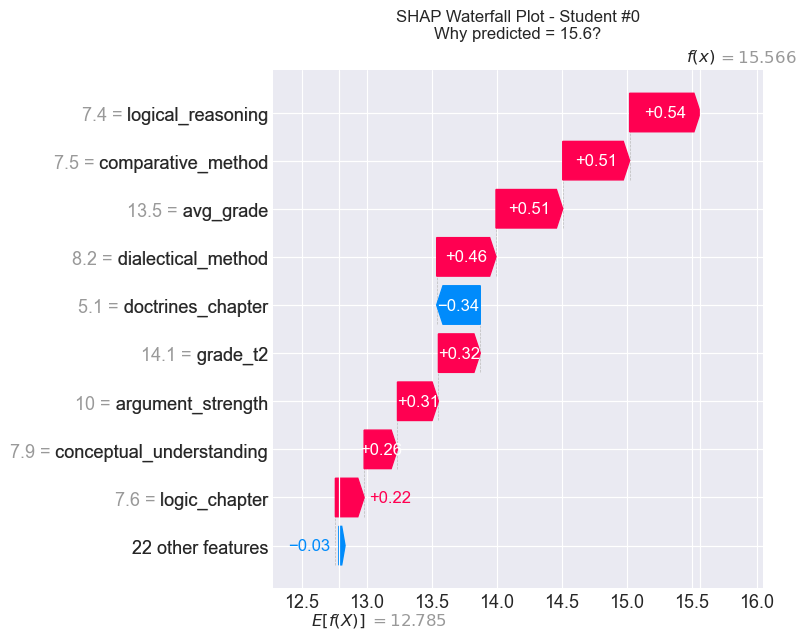


✅ SHAP Explainability Complete


In [30]:
# ============================================
# CELL 13: SHAP EXPLAINABILITY - PHILOSOPHY
# ============================================

import shap
import matplotlib.pyplot as plt

print("=" * 50)
print("SHAP EXPLAINABILITY - PHILOSOPHY")
print("=" * 50)

# Create SHAP explainer
print("\n📊 Creating SHAP explainer...")

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print(f"✅ SHAP explainer created")
print(f"   SHAP values shape: {shap_values.shape}")

# Visualization 1: Feature Importance (SHAP)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance - Philosophy', fontsize=14)
plt.tight_layout()
plt.show()

# Visualization 2: Summary Plot (Beeswarm)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot - Feature Impact Distribution', fontsize=14)
plt.tight_layout()
plt.show()

# Single student explanation
print("\n" + "=" * 50)
print("SINGLE STUDENT EXPLANATION")
print("=" * 50)

student_idx = 0
student_features = X_test.iloc[student_idx:student_idx+1]
student_actual = y_test.iloc[student_idx]
student_pred = model.predict(student_features)[0]

print(f"\n📊 Student #{student_idx}:")
print(f"   Actual score: {student_actual:.1f}")
print(f"   Predicted score: {student_pred:.1f}")

# Waterfall plot
plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[student_idx],
        base_values=explainer.expected_value,
        data=student_features.values[0],
        feature_names=student_features.columns.tolist()
    ),
    show=False
)
plt.title(f'SHAP Waterfall Plot - Student #{student_idx}\nWhy predicted = {student_pred:.1f}?', fontsize=12)
plt.tight_layout()
plt.show()

print("\n" + "=" * 50)
print("✅ SHAP Explainability Complete")
print("=" * 50)

In [33]:
# ============================================
# CELL 14: WEAKNESS ANALYSIS - PHILOSOPHY
# ============================================

from collections import Counter

print("=" * 50)
print("WEAKNESS ANALYSIS - PHILOSOPHY")
print("=" * 50)

# Get feature names and SHAP values
feature_names = X_test.columns.tolist()
shap_values_array = np.array(shap_values)

# Create DataFrame of SHAP values
shap_df = pd.DataFrame(shap_values_array, columns=feature_names)

print("\n📊 Analyzing weaknesses for each student...")

weakness_list = []

for i in range(len(X_test)):
    student_shap = shap_df.iloc[i]
    
    # Weaknesses (negative contributions)
    weaknesses = student_shap[student_shap < 0].sort_values()
    top_weaknesses = weaknesses.head(3)
    
    # Strengths (positive contributions)
    strengths = student_shap[student_shap > 0].sort_values(ascending=False)
    top_strengths = strengths.head(3)
    
    # Safely get strings
    w1 = f"{top_weaknesses.index[0]} ({top_weaknesses.values[0]:.2f})" if len(top_weaknesses) > 0 else "None"
    w2 = f"{top_weaknesses.index[1]} ({top_weaknesses.values[1]:.2f})" if len(top_weaknesses) > 1 else "None"
    w3 = f"{top_weaknesses.index[2]} ({top_weaknesses.values[2]:.2f})" if len(top_weaknesses) > 2 else "None"
    
    s1 = f"{top_strengths.index[0]} (+{top_strengths.values[0]:.2f})" if len(top_strengths) > 0 else "None"
    s2 = f"{top_strengths.index[1]} (+{top_strengths.values[1]:.2f})" if len(top_strengths) > 1 else "None"
    s3 = f"{top_strengths.index[2]} (+{top_strengths.values[2]:.2f})" if len(top_strengths) > 2 else "None"
    
    weakness_list.append({
        'student_id': i,
        'weakness_1': w1,
        'weakness_2': w2,
        'weakness_3': w3,
        'strength_1': s1,
        'strength_2': s2,
        'strength_3': s3,
        'actual_score': y_test.iloc[i],
        'predicted_score': y_pred[i]
    })

weakness_df = pd.DataFrame(weakness_list)

# Display first 10 students
print("\n📋 FIRST 10 STUDENTS - WEAKNESSES & STRENGTHS:")
print("=" * 80)
for i in range(min(10, len(weakness_df))):
    row = weakness_df.iloc[i]
    print(f"\n🔹 STUDENT {i+1}: Actual={row['actual_score']:.1f}, Predicted={row['predicted_score']:.1f}")
    print(f"   🔴 Weaknesses: {row['weakness_1']} | {row['weakness_2']} | {row['weakness_3']}")
    print(f"   🟢 Strengths: {row['strength_1']} | {row['strength_2']} | {row['strength_3']}")

# Most common weaknesses
print("\n" + "=" * 50)
print("MOST COMMON WEAKNESSES (All Students)")
print("=" * 50)

all_weaknesses = []
for i in range(len(weakness_df)):
    for w in [weakness_df.iloc[i]['weakness_1'], weakness_df.iloc[i]['weakness_2'], weakness_df.iloc[i]['weakness_3']]:
        if w != "None":
            feature_name = w.split(' (')[0]
            all_weaknesses.append(feature_name)

weakness_counts = Counter(all_weaknesses)

print("\nTop 15 most frequent weaknesses:")
for feature, count in weakness_counts.most_common(15):
    print(f"   • {feature}: {count} students")

# Recommendations
print("\n" + "=" * 50)
print("💡 RECOMMENDATIONS")
print("=" * 50)

recommendations = {
    # Methodology
    'dialectical_method': '📝 تدرب على المقال الجدلي: أطروحة → نقيض → تركيب',
    'argumentative_method': '🎯 تدرب على المقال الاستقصائي: دفاع عن أطروحة بحجج قوية',
    'comparative_method': '⚖️ تدرب على المقال المقارن: مقارنة موقفين فلسفيين',
    'text_analysis_method': '📄 تدرب على تحليل النص الفلسفي: شرح → تحليل → نقد',
    
    # Thinking Skills
    'logical_reasoning': '🧠 طور منطقك الاستدلالي - تدرب على بناء سلاسل حجاجية',
    'critical_thinking': '🔍 طور تفكيرك النقدي - تعلم نقد الأفكار وليس الأشخاص',
    'conceptual_understanding': '📖 اعمل على فهم المفاهيم الفلسفية المجردة',
    
    # Writing
    'argument_strength': '💪 عزز حججك بأمثلة وأقوال الفلاسفة',
    'essay_structure': '✍️ تعلم هيكلة المقال: مقدمة → عرض → خاتمة',
    'clarity_expression': '🗣️ اعمل على وضوح التعبير والصياغة',
    'use_of_examples': '📚 استخدم أمثلة ملموسة لتوضيح أفكارك',
    
    # Chapters
    'science_philosophy_chapter': '🔬 ركز على فلسفة العلوم: المنهج التجريبي، الحتمية، علوم الإنسان',
    'doctrines_chapter': '📚 راجع المذاهب الفلسفية: عقلانية، تجريبية، براغماتية، وجودية',
    'logic_chapter': '🧮 تدرب على المنطق: القضايا، الاستدلال، الاستقراء',
    'ethics_chapter': '⚖️ راجع الأخلاق: المطلق والنسبي، أسس الفعل الأخلاقي',
    'problem_chapter': '❓ تدرب على صياغة المشكلة والإشكالية',
    'society_politics_chapter': '🏛️ راجع فلسفة المجتمع والسياسة: الدولة، السلطة، القانون',
    
    # Practice
    'essays_written_week': '📝 اكتب مقالين أسبوعياً - الممارسة أساسية في الفلسفة',
    'past_exams': '📚 حل امتحانات سابقة للتعود على نمط الأسئلة'
}

print("\n📋 Based on common weaknesses:")
for feature, count in weakness_counts.most_common(10):
    if feature in recommendations:
        print(f"   • {recommendations[feature]}")
    else:
        print(f"   • {feature}: ركز على تحسين هذا المجال")

# Save
weakness_df.to_csv('weakness_analysis_philo.csv', index=False)
print("\n✅ Weakness analysis saved to 'weakness_analysis_philo.csv'")
print("=" * 50)

WEAKNESS ANALYSIS - PHILOSOPHY

📊 Analyzing weaknesses for each student...

📋 FIRST 10 STUDENTS - WEAKNESSES & STRENGTHS:

🔹 STUDENT 1: Actual=15.9, Predicted=15.6
   🔴 Weaknesses: doctrines_chapter (-0.34) | problem_chapter (-0.10) | argumentative_method (-0.09)
   🟢 Strengths: logical_reasoning (+0.54) | comparative_method (+0.51) | avg_grade (+0.51)

🔹 STUDENT 2: Actual=8.1, Predicted=10.9
   🔴 Weaknesses: logical_reasoning (-0.39) | avg_grade (-0.31) | text_analysis_method (-0.26)
   🟢 Strengths: critical_thinking (+0.32) | argumentative_method (+0.16) | conceptual_understanding (+0.12)

🔹 STUDENT 3: Actual=13.3, Predicted=13.6
   🔴 Weaknesses: dialectical_method (-0.65) | text_analysis_method (-0.36) | ethics_chapter (-0.12)
   🟢 Strengths: avg_grade (+0.97) | grade_t2 (+0.60) | logic_chapter (+0.35)

🔹 STUDENT 4: Actual=11.6, Predicted=12.1
   🔴 Weaknesses: argumentative_method (-0.28) | logical_reasoning (-0.25) | conceptual_understanding (-0.24)
   🟢 Strengths: dialectical_meth

SIMULATION ENGINE - PHILOSOPHY
How improving skills affects your score

👤 Average student profile:
   Current score: 12.8/20
   Dialectical method: 6.4/10
   Logical reasoning: 4.8/10
   Science philosophy: 5.6/10
   Essays/week: 3/10

📈 SIMULATION RESULTS:
-------------------------------------------------------

⚪ 📝 تحسين المنهج الجدلي +2:
   12.8 → 13.0 (+0.24)

⚪ 🎯 تحسين المنهج الاستقصائي +2:
   12.8 → 13.0 (+0.22)

⚪ 🧠 تحسين المنطق والاستدلال +2:
   12.8 → 13.0 (+0.22)

⚪ 🔬 تحسين فلسفة العلوم +2:
   12.8 → 13.0 (+0.20)

⚪ 📚 تحسين معرفة المذاهب الفلسفية +2:
   12.8 → 13.0 (+0.16)

⚪ ⚖️ تحسين منهجية المقال المقارن +2:
   12.8 → 13.0 (+0.18)

⚪ 📄 تحليل النصوص الفلسفية +2:
   12.8 → 13.0 (+0.18)

⚪ ✍️ تحسين هيكلة المقال +2:
   12.8 → 12.9 (+0.14)

⚪ 📖 كتابة مقالين إضافيين أسبوعياً:
   12.8 → 12.9 (+0.05)

⚪ 📚 حل 3 امتحانات سابقة إضافية:
   12.8 → 12.8 (+0.03)

⚪ 😌 تقليل التوتر -2 (تأثير ضئيل):
   12.8 → 12.8 (+0.02)

🟢 ✨ تحسين كل المهارات الأساسية (+2 لكل منها):
   12.8 → 13.9 (+1.08)


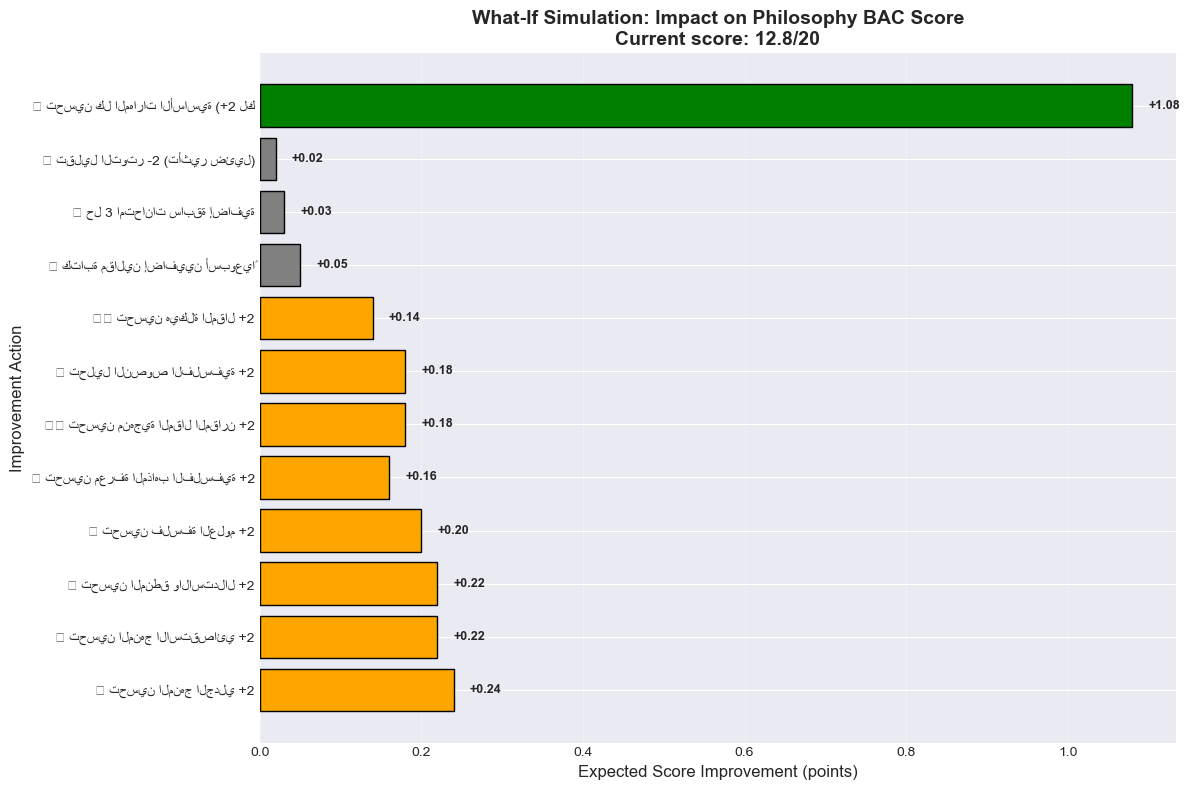


📊 IMPACT TABLE
                 Skill Expected Gain
    📝 المنهج الجدلي +2     +0.24 pts
🎯 المنهج الاستقصائي +2     +0.22 pts
🧠 المنطق والاستدلال +2     +0.22 pts
     🔬 فلسفة العلوم +2     +0.20 pts
 📚 المذاهب الفلسفية +2     +0.16 pts
    ✍️ هيكلة المقال +2     +0.14 pts
📖 مقالين إضافيين/أسبوع     +0.05 pts

💡 KEY INSIGHTS:
   • METHODOLOGY (جدلي + استقصائي) = MOST IMPORTANT
   • LOGICAL REASONING = Essential for all essay types
   • PHILOSOPHY OF SCIENCE = Most important chapter (Gestion stream)
   • WRITING PRACTICE = Write 2 essays/week minimum
   • STRESS has VERY LOW impact - focus on method, not anxiety

✅ Simulation Engine Complete


In [32]:
# ============================================
# CELL 15: SIMULATION ENGINE - PHILOSOPHY
# ============================================

import matplotlib.pyplot as plt

print("=" * 60)
print("SIMULATION ENGINE - PHILOSOPHY")
print("How improving skills affects your score")
print("=" * 60)

# Impact factors (based on correlations)
impact_factors = {
    'dialectical_method': 0.12,
    'argumentative_method': 0.11,
    'logical_reasoning': 0.11,
    'science_philosophy_chapter': 0.10,
    'argument_strength': 0.10,
    'comparative_method': 0.09,
    'text_analysis_method': 0.09,
    'doctrines_chapter': 0.08,
    'logic_chapter': 0.08,
    'critical_thinking': 0.08,
    'essay_structure': 0.07,
    'ethics_chapter': 0.07,
    'problem_chapter': 0.06,
    'society_politics_chapter': 0.06,
    'essays_written_week': 0.05,
    'past_exams': 0.03,
    'stress_level': -0.01
}

# Find average student
avg_bac = df['bac_score_philo'].mean()
target_student = df.iloc[(df['bac_score_philo'] - avg_bac).abs().argsort()[:1]].iloc[0]

print(f"\n👤 Average student profile:")
print(f"   Current score: {target_student['bac_score_philo']:.1f}/20")
print(f"   Dialectical method: {target_student.get('dialectical_method', 5):.1f}/10")
print(f"   Logical reasoning: {target_student.get('logical_reasoning', 5):.1f}/10")
print(f"   Science philosophy: {target_student.get('science_philosophy_chapter', 5):.1f}/10")
print(f"   Essays/week: {target_student.get('essays_written_week', 3):.0f}/10")

# Simulation function
def simulate_improvement(student, improvements):
    original = student['bac_score_philo']
    gain = 0
    
    for skill, delta in improvements.items():
        if skill in impact_factors:
            if skill == 'essays_written_week':
                gain += (delta / 2) * impact_factors[skill]
            elif skill == 'past_exams':
                gain += (delta / 3) * impact_factors[skill]
            else:
                gain += delta * impact_factors[skill]
    
    new_score = min(original + gain, 20)
    new_score = max(new_score, 0)
    return {'original': original, 'new': new_score, 'gain': gain}

# Scenarios
scenarios = [
    ("📝 تحسين المنهج الجدلي +2", {"dialectical_method": 2}),
    ("🎯 تحسين المنهج الاستقصائي +2", {"argumentative_method": 2}),
    ("🧠 تحسين المنطق والاستدلال +2", {"logical_reasoning": 2}),
    ("🔬 تحسين فلسفة العلوم +2", {"science_philosophy_chapter": 2}),
    ("📚 تحسين معرفة المذاهب الفلسفية +2", {"doctrines_chapter": 2}),
    ("⚖️ تحسين منهجية المقال المقارن +2", {"comparative_method": 2}),
    ("📄 تحليل النصوص الفلسفية +2", {"text_analysis_method": 2}),
    ("✍️ تحسين هيكلة المقال +2", {"essay_structure": 2}),
    ("📖 كتابة مقالين إضافيين أسبوعياً", {"essays_written_week": 2}),
    ("📚 حل 3 امتحانات سابقة إضافية", {"past_exams": 3}),
    ("😌 تقليل التوتر -2 (تأثير ضئيل)", {"stress_level": -2}),
    ("✨ تحسين كل المهارات الأساسية (+2 لكل منها)", {
        "dialectical_method": 2, "argumentative_method": 2, "logical_reasoning": 2,
        "science_philosophy_chapter": 2, "argument_strength": 2
    })
]

print(f"\n📈 SIMULATION RESULTS:")
print("-" * 55)

results = []
for name, changes in scenarios:
    result = simulate_improvement(target_student, changes)
    results.append(result)
    
    if result['gain'] > 0.8:
        symbol = "🟢"
    elif result['gain'] > 0.4:
        symbol = "🔵"
    else:
        symbol = "⚪"
    
    print(f"\n{symbol} {name}:")
    print(f"   {result['original']:.1f} → {result['new']:.1f} (+{result['gain']:.2f})")

# Best recommendation
best_idx = max(range(len(results)-1), key=lambda i: results[i]['gain'])
best_scenario = scenarios[best_idx]
best_gain = results[best_idx]['gain']

print("\n" + "=" * 60)
print("🎯 BEST RECOMMENDATION")
print("=" * 60)
print(f"\n✅ {best_scenario[0]}")
print(f"   → Expected improvement: +{best_gain:.2f} points")

# Visualization
fig, ax = plt.subplots(figsize=(12, 8))

scenario_names = [s[0][:35] for s in scenarios]
gains = [r['gain'] for r in results]

colors = ['green' if g > 0.8 else 'blue' if g > 0.4 else 'orange' if g > 0.1 else 'gray' for g in gains]
bars = ax.barh(scenario_names, gains, color=colors, edgecolor='black')

ax.set_xlabel('Expected Score Improvement (points)', fontsize=12)
ax.set_ylabel('Improvement Action', fontsize=12)
ax.set_title(f'What-If Simulation: Impact on Philosophy BAC Score\nCurrent score: {target_student["bac_score_philo"]:.1f}/20', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

for bar, gain in zip(bars, gains):
    if gain > 0:
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, 
                f'+{gain:.2f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "=" * 60)
print("📊 IMPACT TABLE")
print("=" * 60)

impact_table = pd.DataFrame({
    'Skill': [
        '📝 المنهج الجدلي +2',
        '🎯 المنهج الاستقصائي +2',
        '🧠 المنطق والاستدلال +2',
        '🔬 فلسفة العلوم +2',
        '📚 المذاهب الفلسفية +2',
        '✍️ هيكلة المقال +2',
        '📖 مقالين إضافيين/أسبوع'
    ],
    'Expected Gain': [
        f'+{impact_factors["dialectical_method"]*2:.2f} pts',
        f'+{impact_factors["argumentative_method"]*2:.2f} pts',
        f'+{impact_factors["logical_reasoning"]*2:.2f} pts',
        f'+{impact_factors["science_philosophy_chapter"]*2:.2f} pts',
        f'+{impact_factors["doctrines_chapter"]*2:.2f} pts',
        f'+{impact_factors["essay_structure"]*2:.2f} pts',
        f'+{impact_factors["essays_written_week"]:.2f} pts'
    ]
})

print(impact_table.to_string(index=False))

print("\n💡 KEY INSIGHTS:")
print("   • METHODOLOGY (جدلي + استقصائي) = MOST IMPORTANT")
print("   • LOGICAL REASONING = Essential for all essay types")
print("   • PHILOSOPHY OF SCIENCE = Most important chapter (Gestion stream)")
print("   • WRITING PRACTICE = Write 2 essays/week minimum")
print("   • STRESS has VERY LOW impact - focus on method, not anxiety")

print("\n" + "=" * 60)
print("✅ Simulation Engine Complete")
print("=" * 60)

In [34]:
# ============================================
# CELL 16: STUDENT-FRIENDLY FEATURE EXPLANATIONS - PHILOSOPHY
# ============================================

print("=" * 60)
print("📖 فهم نتائجك في الفلسفة")
print("شرح بسيط لكل مهارة تؤثر على نقطتك")
print("=" * 60)

# Sample student
sample_student = df.iloc[50]

print(f"\n👤 ملف الطالب:")
print(f"   النقطة المتوقعة في البكالوريا: {sample_student['bac_score_philo']:.1f}/20")
print(f"   معدل الفصول الثلاثة: {sample_student['avg_grade']:.1f}/20")
print("\n" + "-" * 60)

# Methodology Skills
print("\n📝 المنهجيات (الأكثر أهمية في البكالوريا)")
print("-" * 60)

methodology_skills = [
    ('dialectical_method', '📝 المنهج الجدلي (أطروحة ← نقيض ← تركيب)',
     'تدرب على كتابة مقال جدلي: طرح مشكلة → أطروحة → نقيض → تركيب → حل'),
    ('argumentative_method', '🎯 المنهج الاستقصائي (دفاع عن أطروحة)',
     'تدرب على الدفاع عن أطروحة بحجج قوية ومناقشة موقف الخصوم'),
    ('comparative_method', '⚖️ المنهج المقارن (مقارنة موقفين)',
     'قارن بين مواقف الفلاسفة: أوجه اتفاق واختلاف، ثم حدد موقفك'),
    ('text_analysis_method', '📄 تحليل النص الفلسفي',
     'تعلم تحليل النص: شرح المفردات ← فهم الفكرة العامة ← تحليل ← نقد')
]

for skill, name, advice in methodology_skills:
    if skill in df.columns:
        value = sample_student[skill]
        if value >= 7:
            level = "🟢 قوي"
        elif value >= 5:
            level = "🟡 متوسط"
        else:
            level = "🔴 يحتاج إلى تحسين"
        
        print(f"\n{name}: {value:.1f}/10")
        print(f"   → مستواك: {level}")
        print(f"   💡 نصيحة: {advice}")

# Thinking Skills
print("\n" + "=" * 60)
print("🧠 مهارات التفكير الأساسية")
print("=" * 60)

thinking_skills = [
    ('logical_reasoning', '🧠 الاستدلال المنطقي',
     'طور قدرتك على بناء سلاسل حجاجية منطقية ومترابطة'),
    ('critical_thinking', '🔍 التفكير النقدي',
     'تعلم نقد الأفكار وليس الأشخاص - ابحث عن نقاط الضعف والقوة'),
    ('conceptual_understanding', '📖 الفهم المفاهيمي',
     'افهم المفاهيم الفلسفية المجردة واربطها بالواقع')
]

for skill, name, advice in thinking_skills:
    if skill in df.columns:
        value = sample_student[skill]
        if value >= 7:
            level = "🟢 قوي"
        elif value >= 5:
            level = "🟡 متوسط"
        else:
            level = "🔴 يحتاج إلى تحسين"
        
        print(f"\n{name}: {value:.1f}/10")
        print(f"   → مستواك: {level}")
        print(f"   💡 نصيحة: {advice}")

# Writing Skills
print("\n" + "=" * 60)
print("✍️ مهارات الكتابة والتعبير")
print("=" * 60)

writing_skills = [
    ('essay_structure', '🏗️ هيكلة المقال',
     'التزم ببنية المقال: مقدمة (طرح مشكلة) → عرض (حجج) → خاتمة (حل)'),
    ('argument_strength', '💪 قوة الحجج',
     'دعم حججك بأمثلة ملموسة وأقوال الفلاسفة'),
    ('clarity_expression', '🗣️ وضوح التعبير',
     'استخدم لغة واضحة ومباشرة - تجنب الغموض والتعقيد'),
    ('use_of_examples', '📚 استخدام الأمثلة',
     'أورد أمثلة من الواقع أو التاريخ لتوضيح أفكارك')
]

for skill, name, advice in writing_skills:
    if skill in df.columns:
        value = sample_student[skill]
        if value >= 7:
            level = "🟢 قوي"
        elif value >= 5:
            level = "🟡 متوسط"
        else:
            level = "🔴 يحتاج إلى تحسين"
        
        print(f"\n{name}: {value:.1f}/10")
        print(f"   → مستواك: {level}")
        print(f"   💡 نصيحة: {advice}")

# Chapters Knowledge
print("\n" + "=" * 60)
print("📚 فصول المقرر (المعرفة المحتوى)")
print("=" * 60)

chapters_skills = [
    ('science_philosophy_chapter', '🔬 فلسفة العلوم (الأهم لشعبة تسيير)',
     'ركز على: المنهج التجريبي، الحتمية، علوم الإنسان، البيوتيقا'),
    ('doctrines_chapter', '📚 المذاهب الفلسفية',
     'راجع: العقلانية (ديكارت)، التجريبية (هيوم)، البراغماتية، الوجودية'),
    ('logic_chapter', '🧮 المنطق',
     'تدرب على: القضايا، أنواع الاستدلال، الاستقراء، الاستنباط'),
    ('ethics_chapter', '⚖️ الأخلاق',
     'افهم: الأخلاق المطلقة والنسبية، أسس الفعل الأخلاقي'),
    ('problem_chapter', '❓ المشكلة والإشكالية',
     'تدرب على صياغة المشكلة الفلسفية والإشكالية'),
    ('society_politics_chapter', '🏛️ المجتمع والسياسة',
     'راجع: الدولة، السلطة، القانون، المواطنة، العدالة')
]

for skill, name, advice in chapters_skills:
    if skill in df.columns:
        value = sample_student[skill]
        if value >= 7:
            level = "🟢 قوي"
        elif value >= 5:
            level = "🟡 متوسط"
        else:
            level = "🔴 يحتاج إلى تحسين"
        
        print(f"\n{name}: {value:.1f}/10")
        print(f"   → مستواك: {level}")
        print(f"   💡 نصيحة: {advice}")

# Practice Habits
print("\n" + "=" * 60)
print("📖 عادات الدراسة والممارسة")
print("=" * 60)

print(f"\n📝 مقالات مكتوبة في الأسبوع: {sample_student['essays_written_week']:.0f}/10")
print(f"📄 نصوص محللة في الأسبوع: {sample_student['texts_analyzed_week']:.0f}/10")
print(f"📚 امتحانات سابقة محلولة: {sample_student['past_exams']:.0f}/15")

if sample_student['essays_written_week'] < 4:
    print("   💡 نصيحة: اكتب مقالين أسبوعياً على الأقل - الممارسة أساسية في الفلسفة")
if sample_student['past_exams'] < 5:
    print("   💡 نصيحة: حل 5-6 امتحانات سابقة للتعود على نمط الأسئلة")

# Psychological (LOW impact)
print("\n" + "=" * 60)
print("🧠 العوامل النفسية (تأثيرها ضعيف)")
print("=" * 60)

print(f"\n😰 مستوى التوتر: {sample_student['stress_level']:.1f}/10")
print(f"💪 الثقة: {sample_student['confidence']:.1f}/10")
print(f"❤️ الاهتمام بالفلسفة: {sample_student['interest']:.1f}/10")
print("   💡 نصيحة: التوتر تأثيره ضعيف في الفلسفة - ركز على المنهجية لا القلق!")

# Composite scores
print("\n" + "=" * 60)
print("📊 مؤشراتك المركبة")
print("=" * 60)

method_comp = sample_student.get('methodology_composite', 
    (sample_student['dialectical_method'] + sample_student['argumentative_method'] + 
     sample_student['comparative_method'] + sample_student['text_analysis_method']) / 4)

thinking_comp = sample_student.get('thinking_composite',
    (sample_student['logical_reasoning'] + sample_student['critical_thinking'] + 
     sample_student['conceptual_understanding']) / 3)

writing_comp = sample_student.get('writing_composite',
    (sample_student['essay_structure'] + sample_student['argument_strength'] + 
     sample_student['clarity_expression'] + sample_student['use_of_examples']) / 4)

print(f"\n📝 مستوى المنهجية: {method_comp:.1f}/10")
print(f"🧠 مستوى التفكير: {thinking_comp:.1f}/10")
print(f"✍️ مستوى الكتابة: {writing_comp:.1f}/10")

if method_comp >= 7 and thinking_comp >= 7 and writing_comp >= 7:
    print("   ✅ ممتاز! أنت متوازن بين المنهجية والتفكير والكتابة")
elif method_comp > thinking_comp and method_comp > writing_comp:
    print("   📝 منهجيتك جيدة لكن تفكيرك وكتابتك يحتاجان إلى تحسين")
    print("   💡 ركز على بناء حجج أقوى وتنظيم إجاباتك")
elif thinking_comp > method_comp and thinking_comp > writing_comp:
    print("   🧠 تفكيرك قوي لكن منهجيتك وكتابتك تحتاجان إلى تحسين")
    print("   💡 تعلم هيكلة المقال الجدلي والاستقصائي")
else:
    print("   ✍️ أسلوبك في الكتابة جيد لكن منهجيتك وتفكيرك يحتاجان إلى تحسين")
    print("   💡 تدرب على المنهجيات الأربعة وبناء حجج منطقية")

# Final recommendations
print("\n" + "=" * 60)
print("🎯 توصيات مخصصة لك")
print("=" * 60)

recommendations_list = []

if sample_student['dialectical_method'] < 6:
    recommendations_list.append("• 📝 تدرب على المقال الجدلي (أطروحة ← نقيض ← تركيب)")
if sample_student['argumentative_method'] < 6:
    recommendations_list.append("• 🎯 تدرب على المقال الاستقصائي (دفاع عن أطروحة)")
if sample_student['logical_reasoning'] < 6:
    recommendations_list.append("• 🧠 طور مهاراتك في الاستدلال المنطقي وبناء الحجج")
if sample_student['science_philosophy_chapter'] < 6:
    recommendations_list.append("• 🔬 ركز على فلسفة العلوم - أهم فصل لشعبتك")
if sample_student['essay_structure'] < 6:
    recommendations_list.append("• ✍️ تعلم هيكلة المقال: مقدمة → عرض → خاتمة")
if sample_student['essays_written_week'] < 4:
    recommendations_list.append("• 📝 اكتب مقالين أسبوعياً - الممارسة أساسية")
if sample_student['past_exams'] < 5:
    recommendations_list.append("• 📚 حل 5 امتحانات سابقة على الأقل")

if recommendations_list:
    for rec in recommendations_list[:6]:
        print(f"   {rec}")
else:
    print("   ✅ أنت على الطريق الصحيح! استمر بنفس المستوى")

print("\n" + "=" * 60)
print("✅ تذكر: النجاح في الفلسفة = منهجية صحيحة + تفكير منطقي + كتابة منظمة")
print(f"   نقطتك الحالية: {sample_student['bac_score_philo']:.1f}/20")
print("   مع الالتزام بالنصائح أعلاه، يمكنك رفع نقطتك بمقدار 2-3 نقاط")
print("=" * 60)

📖 فهم نتائجك في الفلسفة
شرح بسيط لكل مهارة تؤثر على نقطتك

👤 ملف الطالب:
   النقطة المتوقعة في البكالوريا: 10.9/20
   معدل الفصول الثلاثة: 12.8/20

------------------------------------------------------------

📝 المنهجيات (الأكثر أهمية في البكالوريا)
------------------------------------------------------------

📝 المنهج الجدلي (أطروحة ← نقيض ← تركيب): 5.0/10
   → مستواك: 🟡 متوسط
   💡 نصيحة: تدرب على كتابة مقال جدلي: طرح مشكلة → أطروحة → نقيض → تركيب → حل

🎯 المنهج الاستقصائي (دفاع عن أطروحة): 7.3/10
   → مستواك: 🟢 قوي
   💡 نصيحة: تدرب على الدفاع عن أطروحة بحجج قوية ومناقشة موقف الخصوم

⚖️ المنهج المقارن (مقارنة موقفين): 4.5/10
   → مستواك: 🔴 يحتاج إلى تحسين
   💡 نصيحة: قارن بين مواقف الفلاسفة: أوجه اتفاق واختلاف، ثم حدد موقفك

📄 تحليل النص الفلسفي: 5.5/10
   → مستواك: 🟡 متوسط
   💡 نصيحة: تعلم تحليل النص: شرح المفردات ← فهم الفكرة العامة ← تحليل ← نقد

🧠 مهارات التفكير الأساسية

🧠 الاستدلال المنطقي: 5.9/10
   → مستواك: 🟡 متوسط
   💡 نصيحة: طور قدرتك على بناء سلاسل حجاجية منطقية ومترابطة


In [35]:
# ============================================
# CELL 17a: INTRODUCTION + BAC EXAM STRUCTURE (PROFESSIONAL) - PHILOSOPHY
# ============================================

from IPython.display import display, HTML

print("=" * 80)
print("📖 منصة تحسين الأداء في الفلسفة - البكالوريا الجزائرية (شعبة تسيير واقتصاد)")
print("=" * 80)

# Create professional HTML layout
intro_html = """
<div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 950px; margin: auto;">

    <!-- Header Section -->
    <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                color: white; padding: 30px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
        <h1 style="margin: 0; font-size: 28px;">📖 امتحان البكالوريا - الفلسفة</h1>
        <p style="margin: 10px 0 0 0; font-size: 16px; opacity: 0.9;">الشعبة: تسيير واقتصاد</p>
        <p style="margin: 5px 0 0 0; font-size: 14px; opacity: 0.8;">المدة: 3 ساعات و30 دقيقة | المجموع: 20 نقطة</p>
    </div>

    <!-- Quick Stats -->
    <div style="display: flex; gap: 15px; margin-bottom: 25px; flex-wrap: wrap;">
        <div style="flex: 1; background: #e8f4f8; padding: 15px; border-radius: 10px; text-align: center; border-right: 4px solid #3498db;">
            <div style="font-size: 35px;">⏱️</div>
            <div style="font-size: 20px; font-weight: bold;">المدة</div>
            <div style="font-size: 14px;">3 ساعات و30 دقيقة</div>
        </div>
        <div style="flex: 1; background: #e8f4f8; padding: 15px; border-radius: 10px; text-align: center; border-right: 4px solid #2ecc71;">
            <div style="font-size: 35px;">📊</div>
            <div style="font-size: 20px; font-weight: bold;">مجموع النقاط</div>
            <div style="font-size: 14px;">20 نقطة</div>
        </div>
        <div style="flex: 1; background: #e8f4f8; padding: 15px; border-radius: 10px; text-align: center; border-right: 4px solid #e74c3c;">
            <div style="font-size: 35px;">📝</div>
            <div style="font-size: 20px; font-weight: bold;">أنواع المقالات</div>
            <div style="font-size: 14px;">3 أنواع + تحليل نص</div>
        </div>
    </div>

    <!-- Exam Structure Title -->
    <div style="background: #2c3e50; color: white; padding: 12px 20px; border-radius: 8px; margin-bottom: 20px;">
        <h2 style="margin: 0; font-size: 20px;">📋 هيكل امتحان البكالوريا في الفلسفة</h2>
    </div>
"""

# Exam structure details
structure_html = """
    <div style="background: #f9f9f9; padding: 15px; border-radius: 10px; margin-bottom: 20px; border-right: 5px solid #3498db;">
        <h3 style="color: #2c3e50; margin-top: 0;">📝 أنواع المقالات في الامتحان</h3>
        <table style="width: 100%; border-collapse: collapse; direction: rtl;">
            <tr style="background: #3498db; color: white;">
                <th style="padding: 10px; text-align: center;">النوع</th>
                <th style="padding: 10px; text-align: center;">الوصف</th>
                <th style="padding: 10px; text-align: center;">البنية</th>
             </tr>
            <tr style="border-bottom: 1px solid #ddd;">
                <td style="padding: 10px;"><strong>📝 المقال الجدلي</strong></td>
                <td style="padding: 10px;">مناقشة أطروحة من خلال عرضها ونقدها وتركيبها</td>
                <td style="padding: 10px;">أطروحة ← نقيض ← تركيب</td>
             </tr>
            <tr style="border-bottom: 1px solid #ddd; background: #f0f8ff;">
                <td style="padding: 10px;"><strong>🎯 المقال الاستقصائي</strong></td>
                <td style="padding: 10px;">الدفاع عن أطروحة مع مناقشة موقف الخصوم</td>
                <td style="padding: 10px;">دفاع ← نقد خصوم ← دفاع شخصي</td>
             </tr>
            <tr style="border-bottom: 1px solid #ddd;">
                <td style="padding: 10px;"><strong>⚖️ المقال المقارن</strong></td>
                <td style="padding: 10px;">مقارنة موقفين فلسفيين مختلفين</td>
                <td style="padding: 10px;">موقف1 ← موقف2 ← مقارنة</td>
             </tr>
            <tr style="background: #f0f8ff;">
                <td style="padding: 10px;"><strong>📄 تحليل النص</strong></td>
                <td style="padding: 10px;">تحليل نص فلسفي: شرح، تحليل، نقد</td>
                <td style="padding: 10px;">شرح ← تحليل ← نقد</td>
             </tr>
        </table>
    </div>
"""

# Importance by skill
importance_html = """
    <div style="background: #fff3cd; padding: 15px; border-radius: 10px; margin-top: 20px; border-right: 5px solid #ffc107;">
        <h3 style="color: #856404; margin-top: 0;">🎯 المهارات الأكثر أهمية</h3>
        <div style="display: flex; gap: 15px; flex-wrap: wrap;">
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #e74c3c; font-size: 24px;">🔴</div>
                <div><strong>المنهجية</strong></div>
                <div style="font-size: 12px; color: #666;">جدلي + استقصائي + مقارن</div>
            </div>
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #e67e22; font-size: 24px;">🟠</div>
                <div><strong>المنطق والاستدلال</strong></div>
                <div style="font-size: 12px; color: #666;">بناء الحجج المنطقية</div>
            </div>
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #f1c40f; font-size: 24px;">🟡</div>
                <div><strong>المحتوى الفلسفي</strong></div>
                <div style="font-size: 12px; color: #666;">المذاهب + فلاسفة + مفاهيم</div>
            </div>
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #2ecc71; font-size: 24px;">🟢</div>
                <div><strong>الكتابة والتعبير</strong></div>
                <div style="font-size: 12px; color: #666;">وضوح + تنظيم + أمثلة</div>
            </div>
        </div>
    </div>
"""

# Critical note
note_html = """
    <div style="background: #f3e5f5; padding: 15px; border-radius: 10px; margin-top: 20px; border-right: 5px solid #9b59b6;">
        <h3 style="color: #4a148c; margin-top: 0;">📋 ملاحظة مهمة</h3>
        <p style="line-height: 1.6;">
            • <strong>المنهجية</strong> هي المفتاح - تعلم أنواع المقالات الثلاثة جيداً<br>
            • <strong>المنطق والاستدلال</strong> أساسيان لبناء حجج قوية ومتماسكة<br>
            • <strong>الممارسة</strong> ضرورية - اكتب مقالين أسبوعياً على الأقل<br>
            • <strong>التوتر تأثيره ضعيف</strong> - ركز على المنهجية وليس القلق<br>
            • <strong>فلسفة العلوم</strong> من أهم الفصول لشعبة تسيير واقتصاد
        </p>
    </div>
"""

# How it works
how_it_works = """
    <div style="background: #e8f8f5; padding: 15px; border-radius: 10px; margin-top: 20px; border-right: 5px solid #1abc9c;">
        <h3 style="color: #0e6655; margin-top: 0;">💡 كيف تعمل هذه المنصة؟</h3>
        <ul style="line-height: 1.8;">
            <li>📝 <strong>أدخل معلوماتك</strong> - مستواك في المنهجيات والمحتوى</li>
            <li>🔮 <strong>توقع نتيجتك</strong> - سنقوم بحساب نقطتك المتوقعة</li>
            <li>📊 <strong>تحليل نقاط القوة والضعف</strong> - هل مشكلتك في المنهجية أم المحتوى؟</li>
            <li>⚡ <strong>محاكاة التحسين</strong> - جرب تحسين مهاراتك وشاهد كيف تتغير نتيجتك</li>
            <li>🎯 <strong>توصيات مخصصة</strong> - نصائح محددة لمساعدتك على رفع نقطتك</li>
        </ul>
    </div>
"""

# Combine all
full_html = intro_html + structure_html + importance_html + note_html + how_it_works + """
    <div style="text-align: center; margin-top: 25px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
        <p style="color: #555; margin: 0;">✨ هذه المنصة تعتمد على تحليل بيانات حقيقية من امتحانات البكالوريا السابقة ✨</p>
        <p style="color: #888; font-size: 12px;">تم تطوير هذه المنصة لمساعدة طلاب البكالوريا (شعبة تسيير واقتصاد) على تحسين أدائهم في الفلسفة</p>
        <p style="color: #888; font-size: 12px;">📖 تذكر: النجاح في الفلسفة = منهجية صحيحة + تفكير منطقي + ممارسة 📖</p>
    </div>
</div>
"""

display(HTML(full_html))

print("\n" + "=" * 80)
print("✅ جاهز للخطوة التالية: إدخال بياناتك الشخصية (الخلية 17b)")
print("=" * 80)

📖 منصة تحسين الأداء في الفلسفة - البكالوريا الجزائرية (شعبة تسيير واقتصاد)


النوع,الوصف,البنية
📝 المقال الجدلي,مناقشة أطروحة من خلال عرضها ونقدها وتركيبها,أطروحة ← نقيض ← تركيب
🎯 المقال الاستقصائي,الدفاع عن أطروحة مع مناقشة موقف الخصوم,دفاع ← نقد خصوم ← دفاع شخصي
⚖️ المقال المقارن,مقارنة موقفين فلسفيين مختلفين,موقف1 ← موقف2 ← مقارنة
📄 تحليل النص,تحليل نص فلسفي: شرح، تحليل، نقد,شرح ← تحليل ← نقد



✅ جاهز للخطوة التالية: إدخال بياناتك الشخصية (الخلية 17b)


In [36]:
# ============================================
# CELL 17b: USER INPUT FORM (PROFESSIONAL) - PHILOSOPHY
# ============================================

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

print("=" * 80)
print("📝 إدخال بيانات الطالب - الفلسفة (شعبة تسيير واقتصاد)")
print("=" * 80)

# Create professional HTML header
form_header = """
<div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
            color: white; padding: 20px; border-radius: 10px; margin-bottom: 25px; text-align: center;">
    <h2 style="margin: 0;">📋 أدخل معلوماتك الدراسية</h2>
    <p style="margin: 10px 0 0 0; opacity: 0.9;">جميع المعلومات سرية وتستخدم فقط لحساب توقع نقطتك</p>
</div>
"""
display(HTML(form_header))

# ============================================
# SECTION 1: Trimester Grades
# ============================================

grades_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #2ecc71;">
    <h3 style="color: #2c3e50; margin-top: 0;">📊 1. معدلات الفصول الثلاثة</h3>
    <p style="color: #666; font-size: 14px;">أدخل معدلاتك من 0 إلى 20</p>
</div>
"""
display(HTML(grades_html))

grade_style = widgets.Layout(width='100%', padding='5px')
grade_slider1 = widgets.FloatSlider(value=12, min=0, max=20, step=0.5, description='الفصل الأول:', 
                                     style={'description_width': '100px'}, layout=grade_style)
grade_slider2 = widgets.FloatSlider(value=12, min=0, max=20, step=0.5, description='الفصل الثاني:', 
                                     style={'description_width': '100px'}, layout=grade_style)
grade_slider3 = widgets.FloatSlider(value=12, min=0, max=20, step=0.5, description='الفصل الثالث:', 
                                     style={'description_width': '100px'}, layout=grade_style)

grades_box = widgets.HBox([grade_slider1, grade_slider2, grade_slider3], 
                          layout=widgets.Layout(justify_content='space-between'))
display(grades_box)

# ============================================
# SECTION 2: Methodology Skills (MOST IMPORTANT)
# ============================================

method_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #e74c3c;">
    <h3 style="color: #2c3e50; margin-top: 0;">📝 2. المنهجيات (الأكثر أهمية!)</h3>
    <p style="color: #666; font-size: 14px;">قيم نفسك من 0 إلى 10 (0=ضعيف، 10=ممتاز)</p>
</div>
"""
display(HTML(method_html))

skill_style = widgets.Layout(width='100%', padding='5px')

dialectical = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                   description='📝 المقال الجدلي (أطروحة ← نقيض ← تركيب):', 
                                   style={'description_width': '300px'}, layout=skill_style)
argumentative = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                     description='🎯 المقال الاستقصائي (دفاع عن أطروحة):', 
                                     style={'description_width': '300px'}, layout=skill_style)
comparative = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                   description='⚖️ المقال المقارن (مقارنة موقفين):', 
                                   style={'description_width': '300px'}, layout=skill_style)
text_analysis = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                     description='📄 تحليل النص الفلسفي:', 
                                     style={'description_width': '300px'}, layout=skill_style)

display(dialectical, argumentative, comparative, text_analysis)

# ============================================
# SECTION 3: Thinking Skills
# ============================================

thinking_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #9b59b6;">
    <h3 style="color: #2c3e50; margin-top: 0;">🧠 3. مهارات التفكير</h3>
    <p style="color: #666; font-size: 14px;">قيم نفسك من 0 إلى 10</p>
</div>
"""
display(HTML(thinking_html))

logical_reasoning = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                         description='🧠 الاستدلال المنطقي:', 
                                         style={'description_width': '250px'}, layout=skill_style)
critical_thinking = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                         description='🔍 التفكير النقدي:', 
                                         style={'description_width': '250px'}, layout=skill_style)
conceptual = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                  description='📖 الفهم المفاهيمي:', 
                                  style={'description_width': '250px'}, layout=skill_style)

display(logical_reasoning, critical_thinking, conceptual)

# ============================================
# SECTION 4: Writing Skills
# ============================================

writing_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #e67e22;">
    <h3 style="color: #2c3e50; margin-top: 0;">✍️ 4. مهارات الكتابة</h3>
    <p style="color: #666; font-size: 14px;">قيم نفسك من 0 إلى 10</p>
</div>
"""
display(HTML(writing_html))

essay_structure = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                       description='🏗️ هيكلة المقال:', 
                                       style={'description_width': '250px'}, layout=skill_style)
argument_strength = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                         description='💪 قوة الحجج:', 
                                         style={'description_width': '250px'}, layout=skill_style)
clarity = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                               description='🗣️ وضوح التعبير:', 
                               style={'description_width': '250px'}, layout=skill_style)
use_examples = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                    description='📚 استخدام الأمثلة:', 
                                    style={'description_width': '250px'}, layout=skill_style)

display(essay_structure, argument_strength, clarity, use_examples)

# ============================================
# SECTION 5: Chapter Knowledge
# ============================================

chapters_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #1abc9c;">
    <h3 style="color: #2c3e50; margin-top: 0;">📚 5. معرفة فصول المقرر</h3>
    <p style="color: #666; font-size: 14px;">قيم معرفتك بكل فصل من 0 إلى 10</p>
</div>
"""
display(HTML(chapters_html))

science_philo = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                     description='🔬 فلسفة العلوم (الأهم لشعبتك):', 
                                     style={'description_width': '280px'}, layout=skill_style)
doctrines = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                 description='📚 المذاهب الفلسفية:', 
                                 style={'description_width': '280px'}, layout=skill_style)
logic = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                             description='🧮 المنطق:', 
                             style={'description_width': '280px'}, layout=skill_style)
ethics = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                              description='⚖️ الأخلاق:', 
                              style={'description_width': '280px'}, layout=skill_style)
problem = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                               description='❓ المشكلة والإشكالية:', 
                               style={'description_width': '280px'}, layout=skill_style)
society = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                               description='🏛️ المجتمع والسياسة:', 
                               style={'description_width': '280px'}, layout=skill_style)

display(science_philo, doctrines, logic, ethics, problem, society)

# ============================================
# SECTION 6: Practice
# ============================================

practice_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #3498db;">
    <h3 style="color: #2c3e50; margin-top: 0;">📝 6. الممارسة والتدريب</h3>
    <p style="color: #666; font-size: 14px;">أدخل عدد التمارين التي تقوم بها أسبوعياً</p>
</div>
"""
display(HTML(practice_html))

essays_week = widgets.IntSlider(value=3, min=0, max=10, step=1, 
                                 description='📝 مقالات مكتوبة أسبوعياً:', 
                                 style={'description_width': '250px'}, layout=skill_style)
texts_week = widgets.IntSlider(value=3, min=0, max=10, step=1, 
                                description='📄 نصوص محللة أسبوعياً:', 
                                style={'description_width': '250px'}, layout=skill_style)
past_exams = widgets.IntSlider(value=3, min=0, max=15, step=1, 
                                description='📚 امتحانات سابقة محلولة:', 
                                style={'description_width': '250px'}, layout=skill_style)

display(essays_week, texts_week, past_exams)

# ============================================
# SECTION 7: Study Behavior
# ============================================

study_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #f39c12;">
    <h3 style="color: #2c3e50; margin-top: 0;">⏰ 7. سلوك الدراسة</h3>
</div>
"""
display(HTML(study_html))

study_hours = widgets.FloatSlider(value=4, min=2, max=12, step=0.5, 
                                   description='⏰ ساعات الدراسة الأسبوعية:', 
                                   style={'description_width': '250px'}, layout=skill_style)
consistency = widgets.FloatSlider(value=6, min=1, max=10, step=0.5, 
                                   description='📅 الانتظام في الدراسة (1-10):', 
                                   style={'description_width': '250px'}, layout=skill_style)
study_method = widgets.FloatSlider(value=6, min=1, max=10, step=0.5, 
                                    description='📖 جودة طريقة الدراسة:', 
                                    style={'description_width': '250px'}, layout=skill_style)

display(study_hours, consistency, study_method)

# ============================================
# SECTION 8: Psychological (LOW impact)
# ============================================

psycho_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #9b59b6;">
    <h3 style="color: #2c3e50; margin-top: 0;">🧠 8. العوامل النفسية (تأثيرها ضعيف)</h3>
    <p style="color: #666; font-size: 14px;">قيم نفسك من 1 إلى 10</p>
</div>
"""
display(HTML(psycho_html))

stress = widgets.FloatSlider(value=5, min=1, max=10, step=0.5, 
                              description='😰 مستوى التوتر:', 
                              style={'description_width': '200px'}, layout=skill_style)
confidence = widgets.FloatSlider(value=6, min=1, max=10, step=0.5, 
                                  description='💪 الثقة في النفس:', 
                                  style={'description_width': '200px'}, layout=skill_style)
interest = widgets.FloatSlider(value=6, min=1, max=10, step=0.5, 
                                description='❤️ الاهتمام بالمادة:', 
                                style={'description_width': '200px'}, layout=skill_style)

display(stress, confidence, interest)

# ============================================
# SUBMIT BUTTON
# ============================================

print("\n" + "=" * 80)
print("🚀 جاهز لحساب توقع نقطتك؟")
print("=" * 80)

submit_button = widgets.Button(
    description='🔮 توقع نتيجتي في البكالوريا (فلسفة)',
    button_style='success',
    icon='check',
    layout=widgets.Layout(width='50%', margin='20px auto', padding='10px')
)
submit_button.style.button_color = '#2ecc71'
submit_button.style.font_weight = 'bold'

# Function to collect inputs
def collect_inputs(b):
    clear_output(wait=True)
    
    # Re-display the form
    display(HTML(form_header))
    display(HTML(grades_html))
    display(grades_box)
    display(HTML(method_html))
    display(dialectical, argumentative, comparative, text_analysis)
    display(HTML(thinking_html))
    display(logical_reasoning, critical_thinking, conceptual)
    display(HTML(writing_html))
    display(essay_structure, argument_strength, clarity, use_examples)
    display(HTML(chapters_html))
    display(science_philo, doctrines, logic, ethics, problem, society)
    display(HTML(practice_html))
    display(essays_week, texts_week, past_exams)
    display(HTML(study_html))
    display(study_hours, consistency, study_method)
    display(HTML(psycho_html))
    display(stress, confidence, interest)
    display(submit_button)
    
    # Collect values
    user_input = {
        'grade_t1': grade_slider1.value,
        'grade_t2': grade_slider2.value,
        'grade_t3': grade_slider3.value,
        'avg_grade': (grade_slider1.value + grade_slider2.value + grade_slider3.value) / 3,
        'dialectical_method': dialectical.value,
        'argumentative_method': argumentative.value,
        'comparative_method': comparative.value,
        'text_analysis_method': text_analysis.value,
        'logical_reasoning': logical_reasoning.value,
        'critical_thinking': critical_thinking.value,
        'conceptual_understanding': conceptual.value,
        'essay_structure': essay_structure.value,
        'argument_strength': argument_strength.value,
        'clarity_expression': clarity.value,
        'use_of_examples': use_examples.value,
        'science_philosophy_chapter': science_philo.value,
        'doctrines_chapter': doctrines.value,
        'logic_chapter': logic.value,
        'ethics_chapter': ethics.value,
        'problem_chapter': problem.value,
        'society_politics_chapter': society.value,
        'essays_written_week': essays_week.value,
        'texts_analyzed_week': texts_week.value,
        'past_exams': past_exams.value,
        'study_hours': study_hours.value,
        'consistency': consistency.value,
        'study_method': study_method.value,
        'stress_level': stress.value,
        'confidence': confidence.value,
        'interest': interest.value
    }
    
    # Store in global variable
    global user_input_data
    user_input_data = user_input
    
    print("\n" + "=" * 80)
    print("✅ تم استلام بياناتك بنجاح!")
    print("=" * 80)
    print("\n📊 ملخص بياناتك:")
    print(f"   معدل الفصل الأول: {grade_slider1.value}/20")
    print(f"   معدل الفصل الثاني: {grade_slider2.value}/20")
    print(f"   معدل الفصل الثالث: {grade_slider3.value}/20")
    print(f"   المنهج الجدلي: {dialectical.value}/10 (الأهم!)")
    print(f"   فلسفة العلوم: {science_philo.value}/10")
    print(f"   مقالات مكتوبة أسبوعياً: {essays_week.value}/10")
    print(f"   التوتر: {stress.value}/10 (تأثير ضعيف)")
    print("\n🔮 انتقل إلى الخلية 17c لرؤية توقع نتيجتك")

submit_button.on_click(collect_inputs)
display(submit_button)

print("\n💡 تذكر: النجاح في الفلسفة = منهجية صحيحة + تفكير منطقي + ممارسة")
print("💡 المنهج الجدلي والمقال الاستقصائي هما الأكثر أهمية!")

📝 إدخال بيانات الطالب - الفلسفة (شعبة تسيير واقتصاد)


FloatSlider(value=6.0, description='📝 المقال الجدلي (أطروحة ← نقيض ← تركيب):', layout=Layout(padding='5px', wi…

FloatSlider(value=6.0, description='🎯 المقال الاستقصائي (دفاع عن أطروحة):', layout=Layout(padding='5px', width…

FloatSlider(value=6.0, description='⚖️ المقال المقارن (مقارنة موقفين):', layout=Layout(padding='5px', width='1…

FloatSlider(value=6.0, description='📄 تحليل النص الفلسفي:', layout=Layout(padding='5px', width='100%'), max=10…

...

FloatSlider(value=6.0, description='💪 الثقة في النفس:', layout=Layout(padding='5px', width='100%'), max=10.0, …

FloatSlider(value=6.0, description='❤️ الاهتمام بالمادة:', layout=Layout(padding='5px', width='100%'), max=10.…


🚀 جاهز لحساب توقع نقطتك؟


Button(button_style='success', description='🔮 توقع نتيجتي في البكالوريا (فلسفة)', icon='check', layout=Layout(…


💡 تذكر: النجاح في الفلسفة = منهجية صحيحة + تفكير منطقي + ممارسة
💡 المنهج الجدلي والمقال الاستقصائي هما الأكثر أهمية!


In [37]:
# ============================================
# CELL 17c: PREDICTION OUTPUT (PROFESSIONAL) - PHILOSOPHY
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

# Check if model exists
if 'model' not in globals():
    print("=" * 80)
    print("⚠️ لم يتم تدريب النموذج بعد!")
    print("=" * 80)
    print("\n📌 يرجى تشغيل الخلية 11 أولاً لتدريب النموذج")
    print("   ثم قم بتشغيل هذه الخلية مرة أخرى")
    print("=" * 80)
elif 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # Calculate derived features
    input_df = pd.DataFrame([user_input_data])
    input_df['grade_trend'] = input_df['grade_t3'] - input_df['grade_t1']
    
    # Methodology composite
    method_cols = ['dialectical_method', 'argumentative_method', 'comparative_method', 'text_analysis_method']
    input_df['methodology_composite'] = input_df[method_cols].mean(axis=1).round(1)
    
    # Thinking composite
    thinking_cols = ['conceptual_understanding', 'logical_reasoning', 'critical_thinking']
    input_df['thinking_composite'] = input_df[thinking_cols].mean(axis=1).round(1)
    
    # Writing composite
    writing_cols = ['essay_structure', 'argument_strength', 'clarity_expression', 'use_of_examples']
    input_df['writing_composite'] = input_df[writing_cols].mean(axis=1).round(1)
    
    # Knowledge composite
    knowledge_cols = ['science_philosophy_chapter', 'doctrines_chapter', 'logic_chapter', 
                      'ethics_chapter', 'problem_chapter', 'society_politics_chapter']
    input_df['knowledge_composite'] = input_df[knowledge_cols].mean(axis=1).round(1)
    
    # Practice intensity
    input_df['practice_intensity'] = (
        input_df['essays_written_week'] / 10 * 10 * 0.4 +
        input_df['texts_analyzed_week'] / 10 * 10 * 0.3 +
        input_df['past_exams'] / 15 * 10 * 0.3
    ).round(1)
    
    # Study quality
    input_df['study_quality'] = (input_df['consistency'] * 0.6 + 
                                  input_df['study_method'] * 0.4).round(1)
    
    # Get model features
    model_features = X_train.columns.tolist()
    for col in model_features:
        if col not in input_df.columns:
            input_df[col] = 0
    
    X_input = input_df[model_features]
    
    # Make prediction
    predicted_score = model.predict(X_input)[0]
    success_prob = 1 / (1 + np.exp(-(predicted_score - 10) / 2)) * 100
    improvement_potential = max(0.5, min((19 - predicted_score) * 0.4, 6))
    
    # Determine level
    if predicted_score >= 16:
        score_color = "#2ecc71"
        score_emoji = "🏆"
        score_text = "ممتاز"
    elif predicted_score >= 14:
        score_color = "#27ae60"
        score_emoji = "🎉"
        score_text = "جيد جداً"
    elif predicted_score >= 12:
        score_color = "#f39c12"
        score_emoji = "👍"
        score_text = "جيد"
    elif predicted_score >= 10:
        score_color = "#e67e22"
        score_emoji = "📈"
        score_text = "مقبول"
    else:
        score_color = "#e74c3c"
        score_emoji = "⚠️"
        score_text = "يحتاج إلى تحسين"
    
    prob_color = "#2ecc71" if success_prob >= 80 else "#f39c12" if success_prob >= 60 else "#e74c3c"
    
    # Methodology vs Thinking vs Writing balance
    method_score = input_df['methodology_composite'].iloc[0]
    thinking_score = input_df['thinking_composite'].iloc[0]
    writing_score = input_df['writing_composite'].iloc[0]
    
    if method_score >= 7 and thinking_score >= 7 and writing_score >= 7:
        balance_text = "✅ متوازن! منهجية + تفكير + كتابة = ممتاز"
        balance_color = "#2ecc71"
    elif method_score >= 7:
        balance_text = "📝 منهجيتك جيدة، لكن تفكيرك وكتابتك تحتاجان إلى تحسين"
        balance_color = "#e67e22"
    elif thinking_score >= 7:
        balance_text = "🧠 تفكيرك قوي، لكن منهجيتك وكتابتك تحتاجان إلى تحسين"
        balance_color = "#e67e22"
    else:
        balance_text = "✍️ كتابتك جيدة، لكن منهجيتك وتفكيرك يحتاجان إلى تحسين"
        balance_color = "#e67e22"
    
    # HTML Output
    prediction_html = f"""
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 950px; margin: auto;">
        
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">🔮 توقع نقطة البكالوريا - الفلسفة</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">بناءً على بياناتك الشخصية</p>
        </div>
        
        <div style="background: linear-gradient(135deg, #8e44ad 0%, #9b59b6 100%); 
                    padding: 30px; border-radius: 20px; margin-bottom: 25px; text-align: center;">
            <div style="font-size: 18px; color: rgba(255,255,255,0.9);">نتيجتك المتوقعة في البكالوريا</div>
            <div style="font-size: 72px; font-weight: bold; color: white; margin: 15px 0;">
                {predicted_score:.1f}<span style="font-size: 32px;">/20</span>
            </div>
            <div style="font-size: 20px; color: white;">
                {score_emoji} مستوى {score_text} {score_emoji}
            </div>
        </div>
        
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px; border-right: 4px solid {score_color};">
                <h3 style="color: #2c3e50; margin-top: 0;">📊 تفاصيل النتيجة</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>🎯 النقطة المتوقعة</span>
                        <span style="font-weight: bold; color: {score_color};">{predicted_score:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>✅ فرصة النجاح (≥10/20)</span>
                        <span style="font-weight: bold; color: {prob_color};">{success_prob:.0f}%</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>📈 إمكانية التحسين</span>
                        <span style="font-weight: bold; color: #3498db;">+{improvement_potential:.1f} نقطة</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; overflow: hidden;">
                    <div style="width: {predicted_score/20*100}%; height: 100%; background: {score_color}; border-radius: 5px;"></div>
                </div>
            </div>
            
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px;">
                <h3 style="color: #2c3e50; margin-top: 0;">👤 معلومات الطالب</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                        <span>📅 معدل الفصل الأول</span>
                        <span style="font-weight: bold;">{user_input_data['grade_t1']:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                        <span>📅 معدل الفصل الثاني</span>
                        <span style="font-weight: bold;">{user_input_data['grade_t2']:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>📅 معدل الفصل الثالث</span>
                        <span style="font-weight: bold;">{user_input_data['grade_t3']:.1f}/20</span>
                    </div>
                </div>
            </div>
        </div>
        
        <div style="background: #f8f9fa; padding: 20px; border-radius: 15px; margin-bottom: 25px;">
            <h3 style="color: #2c3e50; margin-top: 0;">📚 ملخص مهاراتك</h3>
            <div style="display: flex; gap: 15px; flex-wrap: wrap;">
                <div style="flex: 1; min-width: 200px;">
                    <div>📝 المنهجية: <strong>{method_score:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {method_score*10}%; height: 5px; background: #e74c3c; border-radius: 3px;"></div>
                    </div>
                    <div>🧠 التفكير: <strong>{thinking_score:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {thinking_score*10}%; height: 5px; background: #3498db; border-radius: 3px;"></div>
                    </div>
                </div>
                <div style="flex: 1; min-width: 200px;">
                    <div>✍️ الكتابة: <strong>{writing_score:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {writing_score*10}%; height: 5px; background: #2ecc71; border-radius: 3px;"></div>
                    </div>
                    <div>📚 المعرفة: <strong>{input_df['knowledge_composite'].iloc[0]:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {input_df['knowledge_composite'].iloc[0]*10}%; height: 5px; background: #f39c12; border-radius: 3px;"></div>
                    </div>
                </div>
                <div style="flex: 1; min-width: 200px;">
                    <div>📝 المنهج الجدلي: <strong>{user_input_data['dialectical_method']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['dialectical_method']*10}%; height: 5px; background: #e67e22; border-radius: 3px;"></div>
                    </div>
                    <div>😰 مستوى التوتر: <strong>{user_input_data['stress_level']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['stress_level']*10}%; height: 5px; background: #9b59b6; border-radius: 3px;"></div>
                    </div>
                </div>
            </div>
            <div style="margin-top: 15px; padding: 10px; background: #f0f8ff; border-radius: 10px; text-align: center;">
                <p style="margin: 0; color: {balance_color};">{balance_text}</p>
            </div>
        </div>
        
        <div style="background: #fff3cd; padding: 15px; border-radius: 10px; margin-bottom: 25px; border-right: 4px solid #f39c12;">
            <h3 style="color: #856404; margin-top: 0;">📋 ملاحظة مهمة</h3>
            <p style="line-height: 1.6;">
                • <strong>المنهجية</strong> هي المفتاح - تعلم المقال الجدلي والاستقصائي جيداً<br>
                • <strong>المنطق والاستدلال</strong> أساسيان لبناء حجج قوية<br>
                • <strong>الممارسة</strong> ضرورية - اكتب مقالين أسبوعياً على الأقل<br>
                • <strong>التوتر تأثيره ضعيف</strong> (~0.08) - ركز على المنهجية<br>
                • <strong>فلسفة العلوم</strong> من أهم الفصول لشعبتك
            </p>
        </div>
        
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17b', '17b')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ✏️ تعديل البيانات
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17d', '17d')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                📊 تحليل نقاط الضعف →
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ هذه النتيجة هي تقدير بناءً على بياناتك الفعلية ✨</p>
        </div>
    </div>
    """
    
    display(HTML(prediction_html))
    
    # Store prediction
    global student_prediction
    student_prediction = {
        'score': predicted_score,
        'prob': success_prob,
        'improvement': improvement_potential
    }
    
    print("\n" + "=" * 80)
    print("✅ انتقل إلى الخلية 17d لتحليل نقاط الضعف")
    print("=" * 80)


✅ انتقل إلى الخلية 17d لتحليل نقاط الضعف


In [38]:
# ============================================
# CELL 17d: WEAKNESS ANALYSIS (PROFESSIONAL) - PHILOSOPHY
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

# Check if required data exists
if 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
elif 'model' not in globals():
    print("=" * 80)
    print("⚠️ لم يتم تدريب النموذج بعد!")
    print("=" * 80)
    print("📌 يرجى تشغيل الخلية 11 أولاً")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # Target levels for each skill
    skill_targets = {
        'dialectical_method': 7.5,
        'argumentative_method': 7.5,
        'logical_reasoning': 7.0,
        'science_philosophy_chapter': 7.0,
        'argument_strength': 7.0,
        'critical_thinking': 6.5,
        'comparative_method': 6.5,
        'text_analysis_method': 6.5,
        'doctrines_chapter': 6.5,
        'logic_chapter': 6.5,
        'essay_structure': 6.5,
        'ethics_chapter': 6.0,
        'conceptual_understanding': 6.0
    }
    
    # Get user's skill values
    user_skills = {
        'dialectical_method': user_input_data.get('dialectical_method', 5),
        'argumentative_method': user_input_data.get('argumentative_method', 5),
        'logical_reasoning': user_input_data.get('logical_reasoning', 5),
        'science_philosophy_chapter': user_input_data.get('science_philosophy_chapter', 5),
        'argument_strength': user_input_data.get('argument_strength', 5),
        'critical_thinking': user_input_data.get('critical_thinking', 5),
        'comparative_method': user_input_data.get('comparative_method', 5),
        'text_analysis_method': user_input_data.get('text_analysis_method', 5),
        'doctrines_chapter': user_input_data.get('doctrines_chapter', 5),
        'logic_chapter': user_input_data.get('logic_chapter', 5),
        'essay_structure': user_input_data.get('essay_structure', 5),
        'ethics_chapter': user_input_data.get('ethics_chapter', 5),
        'conceptual_understanding': user_input_data.get('conceptual_understanding', 5)
    }
    
    # Calculate gaps
    skill_gaps = {}
    for skill, target in skill_targets.items():
        gap = target - user_skills[skill]
        skill_gaps[skill] = max(0, gap)
    
    sorted_weaknesses = sorted(skill_gaps.items(), key=lambda x: x[1], reverse=True)
    
    # Identify strengths
    strengths = []
    for skill, value in user_skills.items():
        target = skill_targets.get(skill, 6.0)
        if value >= target:
            strengths.append((skill, value - target))
    strengths = sorted(strengths, key=lambda x: x[1], reverse=True)
    
    # Study habits weaknesses
    habit_targets = {
        'essays_written_week': 6,
        'past_exams': 8,
        'study_hours': 5,
        'stress_level': 4,
        'confidence': 7
    }
    
    user_habits = {
        'essays_written_week': user_input_data.get('essays_written_week', 3),
        'past_exams': user_input_data.get('past_exams', 3),
        'study_hours': user_input_data.get('study_hours', 4),
        'stress_level': user_input_data.get('stress_level', 5),
        'confidence': user_input_data.get('confidence', 6)
    }
    
    habit_gaps = {}
    for habit, target in habit_targets.items():
        if habit == 'stress_level':
            gap = user_habits[habit] - target
            if gap > 0:
                habit_gaps[habit] = gap
        else:
            gap = target - user_habits[habit]
            if gap > 0:
                habit_gaps[habit] = gap
    
    sorted_habits = sorted(habit_gaps.items(), key=lambda x: x[1], reverse=True)
    
    # Arabic names
    skill_names_ar = {
        'dialectical_method': '📝 المنهج الجدلي (أطروحة ← نقيض ← تركيب)',
        'argumentative_method': '🎯 المنهج الاستقصائي (دفاع عن أطروحة)',
        'logical_reasoning': '🧠 الاستدلال المنطقي',
        'science_philosophy_chapter': '🔬 فلسفة العلوم',
        'argument_strength': '💪 قوة الحجج',
        'critical_thinking': '🔍 التفكير النقدي',
        'comparative_method': '⚖️ المنهج المقارن',
        'text_analysis_method': '📄 تحليل النص الفلسفي',
        'doctrines_chapter': '📚 المذاهب الفلسفية',
        'logic_chapter': '🧮 المنطق',
        'essay_structure': '🏗️ هيكلة المقال',
        'ethics_chapter': '⚖️ الأخلاق',
        'conceptual_understanding': '📖 الفهم المفاهيمي'
    }
    
    habit_names_ar = {
        'essays_written_week': '📝 المقالات الأسبوعية',
        'past_exams': '📚 الامتحانات السابقة',
        'study_hours': '⏰ ساعات الدراسة',
        'stress_level': '😰 مستوى التوتر',
        'confidence': '💪 الثقة'
    }
    
    # Calculate weakness score
    total_gap = sum(skill_gaps.values()) + sum(habit_gaps.values())
    max_possible_gap = 35
    weakness_score = min(100, int((total_gap / max_possible_gap) * 100))
    
    predicted_score = student_prediction['score'] if 'student_prediction' in globals() else 12.0
    
    # HTML Output
    weakness_html = f"""
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 1000px; margin: auto;">
        
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">📊 تحليل نقاط القوة والضعف</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">فهم مهاراتك لتحديد مجالات التحسين</p>
        </div>
        
        <div style="background: linear-gradient(135deg, #e74c3c 0%, #c0392b 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <div style="font-size: 16px; color: rgba(255,255,255,0.9);">نسبة المجال للتحسين</div>
            <div style="font-size: 48px; font-weight: bold; color: white; margin: 10px 0;">
                {weakness_score}%
            </div>
            <div style="height: 10px; background: rgba(255,255,255,0.3); border-radius: 5px; overflow: hidden; margin-top: 10px;">
                <div style="width: {weakness_score}%; height: 100%; background: white; border-radius: 5px;"></div>
            </div>
            <p style="color: white; margin-top: 15px; font-size: 14px;">
                {'⚠️ هناك مجالات كثيرة تحتاج إلى تحسين' if weakness_score > 60 else '📈 لديك مجالات يمكن تطويرها' if weakness_score > 30 else '✅ أنت على الطريق الصحيح'}
            </p>
        </div>
        
        <div style="background: linear-gradient(135deg, #8e44ad 0%, #9b59b6 100%); 
                    padding: 15px; border-radius: 15px; margin-bottom: 25px; text-align: center; color: white;">
            <div style="font-size: 16px;">نتيجتك المتوقعة حالياً</div>
            <div style="font-size: 36px; font-weight: bold;">{predicted_score:.1f}/20</div>
        </div>
        
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            
            <div style="flex: 1; background: #fff5f5; padding: 20px; border-radius: 15px; border-right: 4px solid #e74c3c;">
                <h3 style="color: #c0392b; margin-top: 0;">🔴 نقاط الضعف</h3>
                <div style="margin: 15px 0;">
    """
    
    weakness_count = 0
    for skill, gap in sorted_weaknesses[:5]:
        if gap > 0:
            weakness_count += 1
            current = user_skills[skill]
            target = skill_targets[skill]
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">{skill_names_ar.get(skill, skill)}</span>
                            <span>{current:.1f}/10 → {target:.1f}</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/target*100}%; height: 100%; background: #e74c3c; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            💡 {'هذه المهارة هي الأهم في البكالوريا! ركز عليها بشدة' if skill in ['dialectical_method', 'argumentative_method', 'logical_reasoning'] else 'هذه المهارة تحتاج إلى مزيد من التدريب'}
                        </p>
                    </div>
            """
    
    for habit, gap in sorted_habits[:3]:
        weakness_count += 1
        current = user_habits[habit]
        target = habit_targets[habit]
        
        advice = {
            'essays_written_week': 'اكتب مقالين أسبوعياً - الممارسة أساسية في الفلسفة',
            'past_exams': 'حل 8-10 امتحانات سابقة للتعود على نمط الأسئلة',
            'study_hours': 'خصص 5 ساعات أسبوعياً للمراجعة والكتابة',
            'stress_level': 'التوتر تأثيره ضعيف جداً - ثق بنفسك!',
            'confidence': 'تدرب بانتظام لتعزيز ثقتك'
        }
        
        if habit == 'stress_level':
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">{habit_names_ar.get(habit, habit)}</span>
                            <span>{current:.0f} → أقل من {target:.0f}</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/10*100}%; height: 100%; background: #e67e22; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            💡 {advice.get(habit, 'حاول تحسين هذه العادة')}
                        </p>
                    </div>
            """
        else:
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">{habit_names_ar.get(habit, habit)}</span>
                            <span>{current:.0f} → {target:.0f}</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {min(current/target*100, 100)}%; height: 100%; background: #e67e22; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            💡 {advice.get(habit, 'حاول تحسين هذه العادة')}
                        </p>
                    </div>
            """
    
    if weakness_count == 0:
        weakness_html += """
                    <div style="text-align: center; padding: 20px;">
                        <p style="color: #27ae60; font-size: 18px;">🎉 ممتاز! لا توجد نقاط ضعف واضحة</p>
                    </div>
        """
    
    weakness_html += """
                </div>
            </div>
            
            <div style="flex: 1; background: #f0fff4; padding: 20px; border-radius: 15px; border-right: 4px solid #27ae60;">
                <h3 style="color: #27ae60; margin-top: 0;">🟢 نقاط القوة</h3>
                <div style="margin: 15px 0;">
    """
    
    if len(strengths) > 0:
        for skill, excess in strengths[:4]:
            skill_name = skill_names_ar.get(skill, skill)
            current = user_skills.get(skill, 5)
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">{skill_name}</span>
                            <span style="color: #27ae60;">{current:.1f}/10</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/10*100}%; height: 100%; background: #27ae60; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">✅ استمر في التدرب للحفاظ على هذا المستوى</p>
                    </div>
            """
    else:
        weakness_html += """
                    <div style="text-align: center; padding: 20px;">
                        <p style="color: #e74c3c;">📚 ركز على تحسين المهارات الأساسية أولاً</p>
                    </div>
        """
    
    weakness_html += """
                </div>
            </div>
        </div>
        
        <div style="background: linear-gradient(135deg, #3498db 0%, #2980b9 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; color: white;">
            <h3 style="margin-top: 0; text-align: center;">🎯 توصيات مخصصة</h3>
            <ul style="line-height: 1.8;">
    """
    
    recommendations = []
    
    if skill_gaps.get('dialectical_method', 0) > 0:
        recommendations.append("📝 <strong>المنهج الجدلي:</strong> تدرب على بنية المقال: أطروحة ← نقيض ← تركيب")
    if skill_gaps.get('argumentative_method', 0) > 0:
        recommendations.append("🎯 <strong>المنهج الاستقصائي:</strong> تعلم الدفاع عن أطروحة بحجج قوية ونقد الخصوم")
    if skill_gaps.get('logical_reasoning', 0) > 0:
        recommendations.append("🧠 <strong>الاستدلال المنطقي:</strong> طور قدرتك على بناء سلاسل حجاجية منطقية")
    if skill_gaps.get('science_philosophy_chapter', 0) > 0:
        recommendations.append("🔬 <strong>فلسفة العلوم:</strong> ركز على المنهج التجريبي، الحتمية، علوم الإنسان - مهم لشعبتك")
    if skill_gaps.get('argument_strength', 0) > 0:
        recommendations.append("💪 <strong>قوة الحجج:</strong> دعم حججك بأمثلة ملموسة وأقوال الفلاسفة")
    if skill_gaps.get('critical_thinking', 0) > 0:
        recommendations.append("🔍 <strong>التفكير النقدي:</strong> تعلم نقد الأفكار وليس الأشخاص")
    if skill_gaps.get('comparative_method', 0) > 0:
        recommendations.append("⚖️ <strong>المنهج المقارن:</strong> تدرب على مقارنة موقفين فلسفيين")
    if skill_gaps.get('text_analysis_method', 0) > 0:
        recommendations.append("📄 <strong>تحليل النص:</strong> تعلم: شرح المفردات ← فهم الفكرة العامة ← تحليل ← نقد")
    
    if habit_gaps.get('essays_written_week', 0) > 0:
        recommendations.append("📝 <strong>الممارسة:</strong> اكتب مقالين أسبوعياً - الممارسة أساسية في الفلسفة")
    if habit_gaps.get('past_exams', 0) > 0:
        recommendations.append("📚 <strong>الامتحانات السابقة:</strong> حل 8-10 امتحانات سابقة للتعود على نمط الأسئلة")
    
    if len(recommendations) == 0:
        recommendations.append("🎉 <strong>أداؤك ممتاز!</strong> استمر على هذا المنوال")
    
    for rec in recommendations[:8]:
        weakness_html += f"<li>{rec}</li>\n"
    
    weakness_html += """
            </ul>
        </div>
        
        <div style="background: #f3e5f5; padding: 15px; border-radius: 10px; margin-bottom: 25px; border-right: 4px solid #9b59b6;">
            <h3 style="color: #4a148c; margin-top: 0;">💡 نصائح سريعة للفلسفة</h3>
            <ul style="line-height: 1.8;">
                <li><strong>المنهجية</strong> هي المفتاح - تعلم أنواع المقالات الثلاثة جيداً</li>
                <li><strong>المنطق والاستدلال</strong> أساسيان لبناء حجج قوية ومتماسكة</li>
                <li><strong>الممارسة</strong> ضرورية - اكتب مقالين أسبوعياً على الأقل</li>
                <li><strong>فلسفة العلوم</strong> من أهم الفصول لشعبة تسيير واقتصاد</li>
                <li><strong>التوتر تأثيره ضعيف</strong> - ركز على المنهجية وليس القلق</li>
            </ul>
        </div>
        
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17c', '17c')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ← العودة للنتيجة
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17e', '17e')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                📖 شرح المؤشرات →
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ التركيز على نقاط الضعف هو المفتاح لتحسين نتائجك ✨</p>
        </div>
    </div>
    """
    
    display(HTML(weakness_html))
    
    print("\n" + "=" * 80)
    print("✅ انتقل إلى الخلية 17e لشرح المؤشرات")
    print("=" * 80)


✅ انتقل إلى الخلية 17e لشرح المؤشرات


In [39]:
# ============================================
# CELL 17e: DERIVED FEATURES EXPLANATION (PROFESSIONAL) - PHILOSOPHY
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

# Check if user_input exists
if 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # Calculate derived features for the user
    methodology_composite = (user_input_data.get('dialectical_method', 5) + 
                             user_input_data.get('argumentative_method', 5) + 
                             user_input_data.get('comparative_method', 5) + 
                             user_input_data.get('text_analysis_method', 5)) / 4
    
    thinking_composite = (user_input_data.get('conceptual_understanding', 5) + 
                          user_input_data.get('logical_reasoning', 5) + 
                          user_input_data.get('critical_thinking', 5)) / 3
    
    writing_composite = (user_input_data.get('essay_structure', 5) + 
                         user_input_data.get('argument_strength', 5) + 
                         user_input_data.get('clarity_expression', 5) + 
                         user_input_data.get('use_of_examples', 5)) / 4
    
    knowledge_composite = (user_input_data.get('science_philosophy_chapter', 5) + 
                           user_input_data.get('doctrines_chapter', 5) + 
                           user_input_data.get('logic_chapter', 5) + 
                           user_input_data.get('ethics_chapter', 5) + 
                           user_input_data.get('problem_chapter', 5) + 
                           user_input_data.get('society_politics_chapter', 5)) / 6
    
    practice_intensity = (user_input_data.get('essays_written_week', 3) / 10 * 10 * 0.4 +
                          user_input_data.get('texts_analyzed_week', 3) / 10 * 10 * 0.3 +
                          user_input_data.get('past_exams', 3) / 15 * 10 * 0.3)
    
    study_quality = (user_input_data.get('consistency', 5) * 0.6 + 
                     user_input_data.get('study_method', 5) * 0.4)
    
    philo_imbalance = abs(methodology_composite - thinking_composite) + abs(thinking_composite - writing_composite)
    philo_imbalance = philo_imbalance / 2
    
    overall_philo = (methodology_composite + thinking_composite + 
                     writing_composite + knowledge_composite) / 4
    
    # Determine levels
    def get_level(value, thresholds):
        if value >= thresholds[0]:
            return "ممتاز", "#2ecc71", "✅"
        elif value >= thresholds[1]:
            return "جيد", "#f39c12", "📈"
        else:
            return "يحتاج إلى تحسين", "#e74c3c", "⚠️"
    
    method_level, method_color, method_icon = get_level(methodology_composite, [7, 5.5])
    thinking_level, thinking_color, thinking_icon = get_level(thinking_composite, [7, 5.5])
    writing_level, writing_color, writing_icon = get_level(writing_composite, [7, 5.5])
    knowledge_level, knowledge_color, knowledge_icon = get_level(knowledge_composite, [7, 5.5])
    practice_level, practice_color, practice_icon = get_level(practice_intensity, [6, 4])
    study_level, study_color, study_icon = get_level(study_quality, [7, 5])
    overall_level, overall_color, overall_icon = get_level(overall_philo, [7, 5.5])
    
    # Imbalance interpretation
    if philo_imbalance < 0.5:
        imbalance_level = "ممتاز (مهارات متوازنة)"
        imbalance_color = "#2ecc71"
        imbalance_icon = "✅"
        imbalance_advice = "مهاراتك متوازنة بين المنهجية والتفكير والكتابة - هذا ممتاز!"
        imbalance_warning = False
    elif philo_imbalance < 1.0:
        imbalance_level = "جيد (تفاوت بسيط)"
        imbalance_color = "#f39c12"
        imbalance_icon = "📈"
        imbalance_advice = "هناك تفاوت بسيط بين مهاراتك. ركز قليلاً على الجانب الأضعف"
        imbalance_warning = False
    else:
        imbalance_level = "يحتاج إلى تحسين (تفاوت كبير)"
        imbalance_color = "#e74c3c"
        imbalance_icon = "⚠️"
        if methodology_composite > thinking_composite and methodology_composite > writing_composite:
            imbalance_advice = "منهجيتك جيدة لكن تفكيرك وكتابتك ضعيفان. ركز على بناء حجج منطقية"
        elif thinking_composite > methodology_composite and thinking_composite > writing_composite:
            imbalance_advice = "تفكيرك قوي لكن منهجيتك وكتابتك ضعيفتان. تعلم هيكلة المقال الجدلي"
        else:
            imbalance_advice = "كتابتك جيدة لكن منهجيتك وتفكيرك يحتاجان إلى تحسين"
        imbalance_warning = True
    
    # Get predicted score
    predicted_score = student_prediction['score'] if 'student_prediction' in globals() else 12.0
    
    # HTML Output
    derived_html = f"""
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 1000px; margin: auto;">
        
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">📖 شرح المؤشرات المركبة</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">ماذا تعني هذه الأرقام؟ وكيف تؤثر على مستواك؟</p>
        </div>
        
        <div style="background: #f0f8ff; padding: 20px; border-radius: 15px; margin-bottom: 25px; border-right: 4px solid #3498db;">
            <p style="font-size: 16px; line-height: 1.6; margin: 0;">
                <strong>📌 ما هي المؤشرات المركبة؟</strong><br>
                هي مقاييس ذكية تستخلص من مهاراتك الأساسية لتعطيك صورة أوضح عن مستواك العام.
            </p>
        </div>
        
        <!-- Card 1: Methodology Composite (MOST IMPORTANT) -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #e74c3c 0%, #c0392b 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">📝 1. مستوى المنهجية - الأهم!</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {method_color};">{methodology_composite:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {method_color};">{method_icon} {method_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {methodology_composite*10}%; height: 100%; background: {method_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;"><strong>أهم مؤشر!</strong> يقيس قدرتك على <strong>تطبيق المنهجيات الأربعة</strong>: المقال الجدلي، المقال الاستقصائي، المقال المقارن، وتحليل النص.</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('تدرب على كتابة مقال جدلي واستقصائي كل أسبوع - هذا هو مفتاح النجاح في البكالوريا!' if methodology_composite < 7 else 'منهجيتك ممتازة! استمر في التدرب على أنواع مختلفة من المقالات')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 2: Thinking Composite -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #3498db 0%, #2980b9 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">🧠 2. مستوى التفكير</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {thinking_color};">{thinking_composite:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {thinking_color};">{thinking_icon} {thinking_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {thinking_composite*10}%; height: 100%; background: {thinking_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">يقيس <strong>مهاراتك الفكرية</strong>: الاستدلال المنطقي، التفكير النقدي، والفهم المفاهيمي.</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('تدرب على بناء سلاسل حجاجية منطقية ونقد الأفكار' if thinking_composite < 7 else 'تفكيرك ممتاز! استمر في تحليل الأفكار')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 3: Writing Composite -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #2ecc71 0%, #27ae60 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">✍️ 3. مستوى الكتابة</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {writing_color};">{writing_composite:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {writing_color};">{writing_icon} {writing_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {writing_composite*10}%; height: 100%; background: {writing_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">يقيس <strong>قدرتك على التعبير الكتابي</strong>: هيكلة المقال، قوة الحجج، وضوح التعبير، واستخدام الأمثلة.</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('اكتب مقالين أسبوعياً وركز على تنظيم الأفكار' if writing_composite < 7 else 'كتابتك ممتازة! استمر في التدرب')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 4: Knowledge Composite -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #f39c12 0%, #e67e22 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">📚 4. المعرفة الفلسفية</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {knowledge_color};">{knowledge_composite:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {knowledge_color};">{knowledge_icon} {knowledge_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {knowledge_composite*10}%; height: 100%; background: {knowledge_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">يقيس معرفتك <strong>بفصول المقرر</strong>: فلسفة العلوم، المذاهب الفلسفية، المنطق، الأخلاق، وغيرها.</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('ركز على فلسفة العلوم - أهم فصل لشعبة تسيير واقتصاد' if knowledge_composite < 7 else 'معرفتك ممتازة! استمر في المراجعة')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 5: Practice Intensity -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #1abc9c 0%, #16a085 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">⚡ 5. كثافة الممارسة</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {practice_color};">{practice_intensity:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {practice_color};">{practice_icon} {practice_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {practice_intensity*10}%; height: 100%; background: {practice_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">يقيس <strong>كمية الممارسة</strong>: المقالات المكتوبة، النصوص المحللة، والامتحانات السابقة.</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('اكتب مقالين أسبوعياً وحل 8-10 امتحانات سابقة' if practice_intensity < 6 else 'مستوى ممارستك ممتاز! استمر')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 6: Balance (Imbalance) -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #9b59b6 0%, #8e44ad 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">⚖️ 6. التوازن بين المهارات</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">نسبة التفاوت:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {imbalance_color};">{philo_imbalance:.2f}</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {imbalance_color};">{imbalance_icon} {imbalance_level}</span>
                    </div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">يقيس الفرق بين <strong>مستوى منهجيتك ومستوى تفكيرك وكتابتك</strong>. القيمة المنخفضة = مهارات متوازنة.</p>
                    <p style="margin: 0;"><strong>💡 نصيحة:</strong><br>{imbalance_advice}</p>
                </div>
            </div>
        </div>
        
        <!-- Summary Card -->
        <div style="background: linear-gradient(135deg, #2c3e50 0%, #34495e 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; color: white;">
            <h3 style="margin-top: 0; text-align: center;">📊 ملخص مؤشراتك</h3>
            <div style="display: flex; gap: 15px; flex-wrap: wrap; justify-content: center;">
                <div style="text-align: center;">
                    <div style="font-size: 24px;">📝</div>
                    <div>المنهجية</div>
                    <div style="font-size: 18px; font-weight: bold;">{methodology_composite:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">🧠</div>
                    <div>التفكير</div>
                    <div style="font-size: 18px; font-weight: bold;">{thinking_composite:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">✍️</div>
                    <div>الكتابة</div>
                    <div style="font-size: 18px; font-weight: bold;">{writing_composite:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">📚</div>
                    <div>المعرفة</div>
                    <div style="font-size: 18px; font-weight: bold;">{knowledge_composite:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">⚡</div>
                    <div>الممارسة</div>
                    <div style="font-size: 18px; font-weight: bold;">{practice_intensity:.1f}/10</div>
                </div>
            </div>
        </div>
        
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17d', '17d')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ← العودة لتحليل الضعف
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17f', '17f')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ⚡ محاكاة التحسين →
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ فهم مؤشراتك يساعدك على تحديد أولويات التحسين ✨</p>
        </div>
    </div>
    """
    
    display(HTML(derived_html))
    
    print("\n" + "=" * 80)
    print("✅ انتقل إلى الخلية 17f لمحاكاة التحسين")
    print("=" * 80)


✅ انتقل إلى الخلية 17f لمحاكاة التحسين


In [40]:
# ============================================
# CELL 17f: SIMULATION ENGINE (PROFESSIONAL) - PHILOSOPHY
# ============================================

from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
import numpy as np
import pandas as pd

# Check if required data exists
if 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
elif 'model' not in globals():
    print("=" * 80)
    print("⚠️ لم يتم تدريب النموذج بعد!")
    print("=" * 80)
    print("📌 يرجى تشغيل الخلية 11 أولاً")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # Impact factors for Philosophy
    impact_factors = {
        'dialectical_method': 0.12,
        'argumentative_method': 0.11,
        'logical_reasoning': 0.11,
        'science_philosophy_chapter': 0.10,
        'argument_strength': 0.10,
        'comparative_method': 0.09,
        'text_analysis_method': 0.09,
        'critical_thinking': 0.08,
        'essay_structure': 0.07,
        'doctrines_chapter': 0.07,
        'logic_chapter': 0.07,
        'essays_written_week': 0.05,
        'past_exams': 0.03,
        'stress_level': -0.01
    }
    
    # Current values from user input
    current_skills = {
        'dialectical_method': user_input_data.get('dialectical_method', 5),
        'argumentative_method': user_input_data.get('argumentative_method', 5),
        'logical_reasoning': user_input_data.get('logical_reasoning', 5),
        'science_philosophy_chapter': user_input_data.get('science_philosophy_chapter', 5),
        'argument_strength': user_input_data.get('argument_strength', 5),
        'comparative_method': user_input_data.get('comparative_method', 5),
        'text_analysis_method': user_input_data.get('text_analysis_method', 5),
        'critical_thinking': user_input_data.get('critical_thinking', 5),
        'essay_structure': user_input_data.get('essay_structure', 5),
        'doctrines_chapter': user_input_data.get('doctrines_chapter', 5),
        'logic_chapter': user_input_data.get('logic_chapter', 5),
        'essays_written_week': user_input_data.get('essays_written_week', 3),
        'past_exams': user_input_data.get('past_exams', 3),
        'stress_level': user_input_data.get('stress_level', 5)
    }
    
    # Current score
    current_score = student_prediction['score'] if 'student_prediction' in globals() else 12.0
    
    print("=" * 80)
    print("⚡ محاكاة تحسين الأداء - الفلسفة")
    print("=" * 80)
    
    simulation_html = """
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 1000px; margin: auto;">
        
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">⚡ محاكاة تحسين الأداء</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">جرّب تحسين مهاراتك وشاهد كيف تتغير نتيجتك</p>
        </div>
        
        <div style="background: #f0f8ff; padding: 20px; border-radius: 15px; margin-bottom: 25px; border-right: 4px solid #3498db;">
            <p style="font-size: 16px; line-height: 1.6; margin: 0;">
                <strong>📌 ملاحظة مهمة:</strong><br>
                • <strong>المنهجية</strong> (جدلي + استقصائي) = الأكثر تأثيراً<br>
                • <strong>المنطق والاستدلال</strong> أساسي لبناء حجج قوية<br>
                • <strong>الممارسة</strong> (كتابة مقالات) ترفع نقطتك بشكل ملحوظ<br>
                • <strong>التوتر</strong> تأثيره ضعيف جداً
            </p>
        </div>
        
        <div style="display: flex; gap: 20px; flex-wrap: wrap;">
            <div style="flex: 1; min-width: 300px;">
                <div style="background: #e74c3c; color: white; padding: 10px; border-radius: 10px; text-align: center; margin-bottom: 15px;">
                    <h3 style="margin: 0;">📝 المنهجيات (الأكثر تأثيراً)</h3>
                </div>
    """
    display(HTML(simulation_html))
    
    print('<div style="max-width: 1000px; margin: auto; direction: rtl; font-family: Cairo, Tahoma, sans-serif;">')
    print('<div style="display: flex; gap: 20px; flex-wrap: wrap;">')
    print('<div style="flex: 1; min-width: 300px;">')
    
    # Methodology sliders (MOST IMPORTANT)
    dialectical_slider = widgets.FloatSlider(
        value=current_skills['dialectical_method'], min=0, max=10, step=0.5,
        description='📝 المنهج الجدلي:',
        style={'description_width': '180px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(dialectical_slider)
    
    argumentative_slider = widgets.FloatSlider(
        value=current_skills['argumentative_method'], min=0, max=10, step=0.5,
        description='🎯 المنهج الاستقصائي:',
        style={'description_width': '180px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(argumentative_slider)
    
    logical_slider = widgets.FloatSlider(
        value=current_skills['logical_reasoning'], min=0, max=10, step=0.5,
        description='🧠 الاستدلال المنطقي:',
        style={'description_width': '180px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(logical_slider)
    
    science_slider = widgets.FloatSlider(
        value=current_skills['science_philosophy_chapter'], min=0, max=10, step=0.5,
        description='🔬 فلسفة العلوم:',
        style={'description_width': '180px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(science_slider)
    
    comparative_slider = widgets.FloatSlider(
        value=current_skills['comparative_method'], min=0, max=10, step=0.5,
        description='⚖️ المنهج المقارن:',
        style={'description_width': '180px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(comparative_slider)
    
    text_slider = widgets.FloatSlider(
        value=current_skills['text_analysis_method'], min=0, max=10, step=0.5,
        description='📄 تحليل النص:',
        style={'description_width': '180px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(text_slider)
    
    print('</div><div style="flex: 1; min-width: 300px;">')
    
    # Writing skills header
    writing_header = """
    <div style="background: #e67e22; color: white; padding: 10px; border-radius: 10px; text-align: center; margin-bottom: 15px;">
        <h3 style="margin: 0;">✍️ مهارات الكتابة</h3>
    </div>
    """
    display(HTML(writing_header))
    
    argument_slider = widgets.FloatSlider(
        value=current_skills['argument_strength'], min=0, max=10, step=0.5,
        description='💪 قوة الحجج:',
        style={'description_width': '180px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(argument_slider)
    
    structure_slider = widgets.FloatSlider(
        value=current_skills['essay_structure'], min=0, max=10, step=0.5,
        description='🏗️ هيكلة المقال:',
        style={'description_width': '180px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(structure_slider)
    
    # Practice header
    practice_header = """
    <div style="background: #1abc9c; color: white; padding: 10px; border-radius: 10px; text-align: center; margin: 15px 0;">
        <h3 style="margin: 0;">📝 الممارسة (تأثير مهم)</h3>
    </div>
    """
    display(HTML(practice_header))
    
    essays_slider = widgets.IntSlider(
        value=current_skills['essays_written_week'], min=0, max=10, step=1,
        description='📝 مقالات أسبوعياً:',
        style={'description_width': '180px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(essays_slider)
    
    exams_slider = widgets.IntSlider(
        value=current_skills['past_exams'], min=0, max=15, step=1,
        description='📚 امتحانات سابقة:',
        style={'description_width': '180px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(exams_slider)
    
    stress_slider = widgets.FloatSlider(
        value=current_skills['stress_level'], min=1, max=10, step=0.5,
        description='😰 مستوى التوتر (تأثير ضعيف):',
        style={'description_width': '180px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(stress_slider)
    
    print('</div></div>')
    
    # Output area
    output = widgets.Output()
    display(output)
    
    # Reset button
    reset_button = widgets.Button(
        description='🔄 إعادة تعيين',
        button_style='warning',
        layout=widgets.Layout(width='200px', margin='20px auto')
    )
    display(reset_button)
    
    # Quick action buttons
    quick_actions_html = """
    <div style="text-align: center; margin: 15px 0;">
        <button id="method_focus" style="background: #e74c3c; color: white; padding: 8px 15px; margin: 5px; border: none; border-radius: 5px; cursor: pointer;">📝 تحسين المنهجية (+2)</button>
        <button id="logic_focus" style="background: #3498db; color: white; padding: 8px 15px; margin: 5px; border: none; border-radius: 5px; cursor: pointer;">🧠 تحسين المنطق (+2)</button>
        <button id="practice_focus" style="background: #2ecc71; color: white; padding: 8px 15px; margin: 5px; border: none; border-radius: 5px; cursor: pointer;">📝 زيادة الممارسة (+2 مقالات)</button>
        <button id="great_improve" style="background: #27ae60; color: white; padding: 8px 15px; margin: 5px; border: none; border-radius: 5px; cursor: pointer;">🏆 تحسين شامل (+3 للكل)</button>
        <button id="reset_all" style="background: #e74c3c; color: white; padding: 8px 15px; margin: 5px; border: none; border-radius: 5px; cursor: pointer;">🔄 إعادة تعيين</button>
    </div>
    """
    display(HTML(quick_actions_html))
    
    # Navigation buttons
    nav_html = """
    <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
        <button onclick="Jupyter.notebook.execute_cell_range('17e', '17e')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
            ← العودة
        </button>
        <button onclick="Jupyter.notebook.execute_cell_range('17g', '17g')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
            📋 التقرير النهائي →
        </button>
    </div>
    """
    display(HTML(nav_html))
    
    print('</div>')
    
    # Update function
    def update_simulation(change):
        with output:
            clear_output(wait=True)
            
            new_skills = {
                'dialectical_method': dialectical_slider.value,
                'argumentative_method': argumentative_slider.value,
                'logical_reasoning': logical_slider.value,
                'science_philosophy_chapter': science_slider.value,
                'argument_strength': argument_slider.value,
                'comparative_method': comparative_slider.value,
                'text_analysis_method': text_slider.value,
                'critical_thinking': current_skills.get('critical_thinking', 5),
                'essay_structure': structure_slider.value,
                'doctrines_chapter': current_skills.get('doctrines_chapter', 5),
                'logic_chapter': current_skills.get('logic_chapter', 5),
                'essays_written_week': essays_slider.value,
                'past_exams': exams_slider.value,
                'stress_level': stress_slider.value
            }
            
            # Calculate total gain
            total_gain = 0
            
            for skill, impact in impact_factors.items():
                if skill in new_skills:
                    if skill == 'essays_written_week':
                        gain = (new_skills[skill] - current_skills[skill]) / 2 * impact
                    elif skill == 'past_exams':
                        gain = (new_skills[skill] - current_skills[skill]) / 3 * impact
                    elif skill == 'stress_level':
                        gain = (current_skills[skill] - new_skills[skill]) * abs(impact)
                    else:
                        gain = (new_skills[skill] - current_skills[skill]) * impact
                    
                    if abs(gain) > 0.01:
                        total_gain += gain
            
            new_score = min(current_score + total_gain, 20)
            new_score = max(new_score, 0)
            
            # Color based on new score
            if new_score >= 16:
                score_color = "#2ecc71"
                score_emoji = "🏆"
            elif new_score >= 14:
                score_color = "#27ae60"
                score_emoji = "🎉"
            elif new_score >= 12:
                score_color = "#f39c12"
                score_emoji = "👍"
            elif new_score >= 10:
                score_color = "#e67e22"
                score_emoji = "📈"
            else:
                score_color = "#e74c3c"
                score_emoji = "⚠️"
            
            # Result HTML
            result_html = f"""
            <div style="background: #f8f9fa; border-radius: 15px; padding: 20px; margin-top: 20px; border-right: 4px solid {score_color};">
                <h3 style="color: #2c3e50; margin-top: 0; text-align: center;">📊 نتيجة المحاكاة</h3>
                
                <div style="text-align: center; margin: 20px 0;">
                    <div style="font-size: 16px; color: #666;">نقطتك المتوقعة بعد التحسين</div>
                    <div style="font-size: 64px; font-weight: bold; color: {score_color};">
                        {new_score:.1f}<span style="font-size: 24px;">/20</span>
                    </div>
                    <div style="font-size: 18px; margin-top: 10px;">
                        {score_emoji} {'تحسن ملحوظ 📈' if total_gain > 1 else 'تحسن طفيف' if total_gain > 0 else 'بدون تغيير' if total_gain == 0 else 'انخفاض 📉'} {score_emoji}
                    </div>
                    <div style="font-size: 14px; color: #666; margin-top: 5px;">
                        (من {current_score:.1f} إلى {new_score:.1f})
                    </div>
                </div>
                
                <div style="background: #f0f8ff; padding: 15px; border-radius: 10px;">
                    <div style="display: flex; justify-content: space-between; font-weight: bold;">
                        <span>📈 إجمالي التحسن</span>
                        <span style="color: {'#2ecc71' if total_gain > 0 else '#e74c3c'};">{'+' if total_gain > 0 else ''}{total_gain:.2f} نقطة</span>
                    </div>
                </div>
                
                <div style="background: #fff3cd; padding: 15px; border-radius: 10px; margin-top: 15px;">
                    <p style="margin: 0;"><strong>💡 نصيحة:</strong><br>
                    • <strong>المنهجية</strong> (جدلي + استقصائي) = الأكثر تأثيراً<br>
                    • <strong>الممارسة</strong> - اكتب مقالين أسبوعياً على الأقل<br>
                    • <strong>فلسفة العلوم</strong> من أهم الفصول لشعبتك
                    </p>
                </div>
            </div>
            """
            
            display(HTML(result_html))
    
    # Reset function
    def reset_simulation(b):
        dialectical_slider.value = current_skills['dialectical_method']
        argumentative_slider.value = current_skills['argumentative_method']
        logical_slider.value = current_skills['logical_reasoning']
        science_slider.value = current_skills['science_philosophy_chapter']
        argument_slider.value = current_skills['argument_strength']
        comparative_slider.value = current_skills['comparative_method']
        text_slider.value = current_skills['text_analysis_method']
        structure_slider.value = current_skills['essay_structure']
        essays_slider.value = current_skills['essays_written_week']
        exams_slider.value = current_skills['past_exams']
        stress_slider.value = current_skills['stress_level']
    
    # Quick improve functions
    def method_focus(b):
        dialectical_slider.value = min(dialectical_slider.value + 2, 10)
        argumentative_slider.value = min(argumentative_slider.value + 2, 10)
        comparative_slider.value = min(comparative_slider.value + 2, 10)
        text_slider.value = min(text_slider.value + 2, 10)
    
    def logic_focus(b):
        logical_slider.value = min(logical_slider.value + 2, 10)
        science_slider.value = min(science_slider.value + 2, 10)
        argument_slider.value = min(argument_slider.value + 2, 10)
        structure_slider.value = min(structure_slider.value + 2, 10)
    
    def practice_focus(b):
        essays_slider.value = min(essays_slider.value + 2, 10)
        exams_slider.value = min(exams_slider.value + 3, 15)
    
    def great_improve(b):
        for slider in [dialectical_slider, argumentative_slider, logical_slider, science_slider, 
                       argument_slider, comparative_slider, text_slider, structure_slider]:
            slider.value = min(slider.value + 3, 10)
        essays_slider.value = min(essays_slider.value + 3, 10)
        exams_slider.value = min(exams_slider.value + 5, 15)
    
    # Attach events
    dialectical_slider.observe(update_simulation, names='value')
    argumentative_slider.observe(update_simulation, names='value')
    logical_slider.observe(update_simulation, names='value')
    science_slider.observe(update_simulation, names='value')
    argument_slider.observe(update_simulation, names='value')
    comparative_slider.observe(update_simulation, names='value')
    text_slider.observe(update_simulation, names='value')
    structure_slider.observe(update_simulation, names='value')
    essays_slider.observe(update_simulation, names='value')
    exams_slider.observe(update_simulation, names='value')
    stress_slider.observe(update_simulation, names='value')
    reset_button.on_click(reset_simulation)
    
    # JavaScript for quick buttons
    from IPython.display import Javascript
    display(Javascript("""
    setTimeout(function() {
        document.getElementById('method_focus')?.addEventListener('click', () => {
            var btn = document.getElementById('method_focus');
            if (btn) btn.click();
        });
        document.getElementById('logic_focus')?.addEventListener('click', () => {
            var btn = document.getElementById('logic_focus');
            if (btn) btn.click();
        });
        document.getElementById('practice_focus')?.addEventListener('click', () => {
            var btn = document.getElementById('practice_focus');
            if (btn) btn.click();
        });
        document.getElementById('great_improve')?.addEventListener('click', () => {
            var btn = document.getElementById('great_improve');
            if (btn) btn.click();
        });
        document.getElementById('reset_all')?.addEventListener('click', () => {
            var btn = document.getElementById('reset_all');
            if (btn) btn.click();
        });
    }, 100);
    """))
    
    # Initial update
    update_simulation(None)
    
    print("\n" + "=" * 80)
    print("✅ انتقل إلى الخلية 17g للتقرير النهائي")
    print("=" * 80)

⚡ محاكاة تحسين الأداء - الفلسفة


<div style="max-width: 1000px; margin: auto; direction: rtl; font-family: Cairo, Tahoma, sans-serif;">
<div style="display: flex; gap: 20px; flex-wrap: wrap;">
<div style="flex: 1; min-width: 300px;">


FloatSlider(value=6.0, description='📝 المنهج الجدلي:', layout=Layout(margin='10px 0', width='100%'), max=10.0,…

FloatSlider(value=6.0, description='🎯 المنهج الاستقصائي:', layout=Layout(margin='10px 0', width='100%'), max=1…

FloatSlider(value=6.0, description='🧠 الاستدلال المنطقي:', layout=Layout(margin='10px 0', width='100%'), max=1…

...

Output()

Button(button_style='warning', description='🔄 إعادة تعيين', layout=Layout(margin='20px auto', width='200px'), …

</div>


<IPython.core.display.Javascript object>


✅ انتقل إلى الخلية 17g للتقرير النهائي


In [41]:
# ============================================
# CELL 17g: FINAL REPORT (PROFESSIONAL) - PHILOSOPHY
# ============================================

from IPython.display import display, HTML, clear_output
from datetime import datetime

# Check if required data exists
if 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
elif 'model' not in globals():
    print("=" * 80)
    print("⚠️ لم يتم تدريب النموذج بعد!")
    print("=" * 80)
    print("📌 يرجى تشغيل الخلية 11 أولاً")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # Calculate all metrics
    predicted_score = student_prediction['score'] if 'student_prediction' in globals() else 12.0
    success_prob = student_prediction['prob'] if 'student_prediction' in globals() else 50.0
    improvement_potential = student_prediction['improvement'] if 'student_prediction' in globals() else 3.0
    
    # Calculate composite scores
    methodology_composite = (user_input_data.get('dialectical_method', 5) + 
                             user_input_data.get('argumentative_method', 5) + 
                             user_input_data.get('comparative_method', 5) + 
                             user_input_data.get('text_analysis_method', 5)) / 4
    
    thinking_composite = (user_input_data.get('logical_reasoning', 5) + 
                          user_input_data.get('critical_thinking', 5) + 
                          user_input_data.get('conceptual_understanding', 5)) / 3
    
    writing_composite = (user_input_data.get('essay_structure', 5) + 
                         user_input_data.get('argument_strength', 5) + 
                         user_input_data.get('clarity_expression', 5) + 
                         user_input_data.get('use_of_examples', 5)) / 4
    
    # Determine score level
    if predicted_score >= 16:
        score_level = "ممتاز"
        score_level_color = "#2ecc71"
        score_level_icon = "🏆"
        score_message = "مستواك ممتاز! أنت على الطريق الصحيح لتحقيق نتيجة مميزة."
    elif predicted_score >= 14:
        score_level = "جيد جداً"
        score_level_color = "#27ae60"
        score_level_icon = "🎉"
        score_message = "مستواك جيد جداً! مع القليل من التحسين يمكنك الوصول إلى الامتياز."
    elif predicted_score >= 12:
        score_level = "جيد"
        score_level_color = "#f39c12"
        score_level_icon = "👍"
        score_message = "مستواك جيد. هناك مجالات للتحسين يمكن أن ترفع نقطتك."
    elif predicted_score >= 10:
        score_level = "مقبول"
        score_level_color = "#e67e22"
        score_level_icon = "📈"
        score_message = "مستواك مقبول. تحتاج إلى العمل على بعض المهارات الأساسية."
    else:
        score_level = "يحتاج إلى تحسين"
        score_level_color = "#e74c3c"
        score_level_icon = "⚠️"
        score_message = "مستواك يحتاج إلى تحسين. لا تقلق! مع الالتزام بالنصائح يمكنك التقدم."
    
    # Identify top weaknesses
    weaknesses = []
    skills_data = [
        ('dialectical_method', '📝 المنهج الجدلي', 7.5, user_input_data.get('dialectical_method', 5)),
        ('argumentative_method', '🎯 المنهج الاستقصائي', 7.5, user_input_data.get('argumentative_method', 5)),
        ('logical_reasoning', '🧠 الاستدلال المنطقي', 7.0, user_input_data.get('logical_reasoning', 5)),
        ('science_philosophy_chapter', '🔬 فلسفة العلوم', 7.0, user_input_data.get('science_philosophy_chapter', 5)),
        ('argument_strength', '💪 قوة الحجج', 7.0, user_input_data.get('argument_strength', 5)),
        ('comparative_method', '⚖️ المنهج المقارن', 6.5, user_input_data.get('comparative_method', 5)),
        ('text_analysis_method', '📄 تحليل النص', 6.5, user_input_data.get('text_analysis_method', 5))
    ]
    
    for skill_key, skill_name, target, current in skills_data:
        if current < target:
            weaknesses.append((skill_name, current, target, target - current))
    
    weaknesses.sort(key=lambda x: x[3], reverse=True)
    top_weaknesses = weaknesses[:3]
    
    # Study habits
    weak_habits = []
    good_habits = []
    habits_data = [
        ('essays_written_week', '📝 المقالات الأسبوعية', 6, user_input_data.get('essays_written_week', 3)),
        ('past_exams', '📚 الامتحانات السابقة', 8, user_input_data.get('past_exams', 3)),
        ('study_hours', '⏰ ساعات الدراسة', 5, user_input_data.get('study_hours', 4)),
        ('stress_level', '😰 مستوى التوتر', 4, user_input_data.get('stress_level', 5)),
        ('confidence', '💪 الثقة', 7, user_input_data.get('confidence', 6))
    ]
    
    for habit_key, habit_name, target, current in habits_data:
        if habit_key == 'stress_level':
            if current > target:
                weak_habits.append((habit_name, current, target))
            else:
                good_habits.append((habit_name, current, target))
        else:
            if current < target:
                weak_habits.append((habit_name, current, target))
            else:
                good_habits.append((habit_name, current, target))
    
    current_date = datetime.now().strftime("%d/%m/%Y")
    
    # HTML Output
    final_html = f"""
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 1000px; margin: auto;">
        
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">📋 التقرير النهائي</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">الفلسفة</p>
            <p style="margin: 5px 0 0 0; font-size: 12px; opacity: 0.7;">{current_date}</p>
        </div>
        
        <div style="background: white; border-radius: 15px; margin-bottom: 25px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, {score_level_color} 0%, {score_level_color}80 100%); 
                        padding: 20px; text-align: center; color: white;">
                <div style="font-size: 18px;">نتيجتك المتوقعة في البكالوريا</div>
                <div style="font-size: 64px; font-weight: bold;">{predicted_score:.1f}<span style="font-size: 24px;">/20</span></div>
                <div style="font-size: 20px;">{score_level_icon} مستوى {score_level} {score_level_icon}</div>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; gap: 15px; flex-wrap: wrap; justify-content: space-around;">
                    <div style="text-align: center;">
                        <div style="font-size: 14px; color: #666;">فرصة النجاح</div>
                        <div style="font-size: 24px; font-weight: bold; color: {'#2ecc71' if success_prob >= 70 else '#f39c12' if success_prob >= 50 else '#e74c3c'};">{success_prob:.0f}%</div>
                    </div>
                    <div style="text-align: center;">
                        <div style="font-size: 14px; color: #666;">إمكانية التحسين</div>
                        <div style="font-size: 24px; font-weight: bold; color: #3498db;">+{improvement_potential:.1f}</div>
                    </div>
                    <div style="text-align: center;">
                        <div style="font-size: 14px; color: #666;">مستوى المنهجية</div>
                        <div style="font-size: 24px; font-weight: bold;">{methodology_composite:.1f}/10</div>
                    </div>
                    <div style="text-align: center;">
                        <div style="font-size: 14px; color: #666;">مستوى التفكير</div>
                        <div style="font-size: 24px; font-weight: bold;">{thinking_composite:.1f}/10</div>
                    </div>
                </div>
                <div style="margin-top: 15px; padding: 10px; background: #f8f9fa; border-radius: 10px; text-align: center;">
                    <p style="margin: 0; color: #555;">{score_message}</p>
                </div>
            </div>
        </div>
        
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            <div style="flex: 1; background: #fff5f5; padding: 20px; border-radius: 15px; border-right: 4px solid #e74c3c;">
                <h3 style="color: #c0392b; margin-top: 0;">🔴 نقاط الضعف</h3>
    """
    
    if top_weaknesses:
        for name, current, target, gap in top_weaknesses:
            final_html += f"""
                <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                        <span style="font-weight: bold;">{name}</span>
                        <span>{current:.1f}/10 → {target:.1f}</span>
                    </div>
                    <div style="height: 6px; background: #ecf0f1; border-radius: 3px;">
                        <div style="width: {current/target*100}%; height: 6px; background: #e74c3c; border-radius: 3px;"></div>
                    </div>
                </div>
            """
    else:
        final_html += '<p style="color: #27ae60;">🎉 ممتاز! لا توجد نقاط ضعف واضحة</p>'
    
    final_html += """
            </div>
            <div style="flex: 1; background: #f0fff4; padding: 20px; border-radius: 15px; border-right: 4px solid #27ae60;">
                <h3 style="color: #27ae60; margin-top: 0;">🟢 نقاط القوة</h3>
    """
    
    strengths = []
    for skill_key, skill_name, target, current in skills_data:
        if current >= target:
            strengths.append((skill_name, current))
    strengths.sort(key=lambda x: x[1], reverse=True)
    
    if strengths:
        for name, current in strengths[:3]:
            final_html += f"""
                <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                        <span style="font-weight: bold;">{name}</span>
                        <span style="color: #27ae60;">{current:.1f}/10</span>
                    </div>
                    <div style="height: 6px; background: #ecf0f1; border-radius: 3px;">
                        <div style="width: {current/10*100}%; height: 6px; background: #27ae60; border-radius: 3px;"></div>
                    </div>
                </div>
            """
    else:
        final_html += '<p style="color: #e74c3c;">📚 ركز على تحسين المهارات الأساسية</p>'
    
    final_html += """
            </div>
        </div>
        
        <div style="background: #f8f9fa; border-radius: 15px; padding: 20px; margin-bottom: 25px;">
            <h3 style="color: #2c3e50; margin-top: 0;">📖 عادات الدراسة</h3>
            <div style="display: flex; gap: 20px; flex-wrap: wrap;">
                <div style="flex: 1;">
                    <p style="color: #e67e22; font-weight: bold;">⚠️ تحتاج إلى تحسين:</p>
    """
    
    if weak_habits:
        for name, current, target in weak_habits:
            if name == 'مستوى التوتر':
                final_html += f"""
                    <div style="margin-bottom: 10px;">
                        <span>{name}: {current:.0f} → أقل من {target:.0f}</span>
                        <div style="height: 4px; background: #ecf0f1; border-radius: 2px; margin-top: 3px;">
                            <div style="width: {current/10*100}%; height: 4px; background: #e67e22; border-radius: 2px;"></div>
                        </div>
                    </div>
                """
            else:
                final_html += f"""
                    <div style="margin-bottom: 10px;">
                        <span>{name}: {current:.0f} → {target:.0f}</span>
                        <div style="height: 4px; background: #ecf0f1; border-radius: 2px; margin-top: 3px;">
                            <div style="width: {current/target*100}%; height: 4px; background: #e67e22; border-radius: 2px;"></div>
                        </div>
                    </div>
                """
    else:
        final_html += '<p style="color: #27ae60;">✅ جميع عاداتك الدراسية جيدة!</p>'
    
    final_html += """
                </div>
                <div style="flex: 1;">
                    <p style="color: #27ae60; font-weight: bold;">✅ جيد:</p>
    """
    
    if good_habits:
        for name, current, target in good_habits:
            final_html += f"""
                    <div style="margin-bottom: 10px;">
                        <span>{name}: {current:.0f}/{target:.0f}</span>
                        <div style="height: 4px; background: #ecf0f1; border-radius: 2px; margin-top: 3px;">
                            <div style="width: {min(current/target*100, 100)}%; height: 4px; background: #27ae60; border-radius: 2px;"></div>
                        </div>
                    </div>
            """
    else:
        final_html += '<p>لا توجد عادات جيدة حالياً</p>'
    
    final_html += f"""
                </div>
            </div>
        </div>
        
        <div style="background: linear-gradient(135deg, #8e44ad 0%, #9b59b6 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; color: white;">
            <h3 style="margin-top: 0; text-align: center;">🎯 خطة العمل</h3>
            <div style="display: flex; gap: 15px; flex-wrap: wrap;">
                <div style="flex: 1; background: rgba(255,255,255,0.1); padding: 15px; border-radius: 10px;">
                    <h4 style="margin: 0 0 10px 0;">📝 الأسبوع 1-2</h4>
                    <ul style="margin: 0; padding-right: 20px;">
                        <li>تعلم <strong>المنهج الجدلي</strong> (أطروحة ← نقيض ← تركيب)</li>
                        <li>تدرب على <strong>تحليل النصوص الفلسفية</strong></li>
                        <li>اكتب <strong>مقالين أسبوعياً</strong></li>
                    </ul>
                </div>
                <div style="flex: 1; background: rgba(255,255,255,0.1); padding: 15px; border-radius: 10px;">
                    <h4 style="margin: 0 0 10px 0;">🧠 الأسبوع 3-4</h4>
                    <ul style="margin: 0; padding-right: 20px;">
                        <li>ركز على <strong>المنهج الاستقصائي</strong> (دفاع عن أطروحة)</li>
                        <li>طور <strong>الاستدلال المنطقي</strong> وبناء الحجج</li>
                        <li>راجع <strong>فلسفة العلوم</strong> (مهم لشعبتك)</li>
                    </ul>
                </div>
                <div style="flex: 1; background: rgba(255,255,255,0.1); padding: 15px; border-radius: 10px;">
                    <h4 style="margin: 0 0 10px 0;">🏆 الأسبوع 5-6</h4>
                    <ul style="margin: 0; padding-right: 20px;">
                        <li>حل <strong>امتحانات سابقة كاملة</strong> (8-10 امتحانات)</li>
                        <li>راجع <strong>المنهج المقارن وتحليل النص</strong></li>
                        <li>وازن بين <strong>المنهجية والتفكير والكتابة</strong></li>
                    </ul>
                </div>
            </div>
        </div>
        
        <div style="background: #f3e5f5; padding: 15px; border-radius: 10px; margin-bottom: 25px; border-right: 4px solid #9b59b6;">
            <h3 style="color: #4a148c; margin-top: 0;">💡 نصائح خاصة للفلسفة</h3>
            <ul style="line-height: 1.8;">
                <li><strong>المنهجية</strong> هي المفتاح - تعلم أنواع المقالات الثلاثة جيداً</li>
                <li><strong>المنطق والاستدلال</strong> أساسيان لبناء حجج قوية ومتماسكة</li>
                <li><strong>الممارسة</strong> ضرورية - اكتب مقالين أسبوعياً على الأقل</li>
                <li><strong>فلسفة العلوم</strong> من أهم الفصول لشعبة تسيير واقتصاد</li>
                <li><strong>التوتر تأثيره ضعيف</strong> - ركز على المنهجية وليس القلق</li>
            </ul>
        </div>
        
        <div style="background: #e8f8f5; padding: 20px; border-radius: 15px; text-align: center;">
            <p style="font-size: 18px; margin: 0; color: #0e6655;">
                🌟 مع الالتزام بخطة العمل، يمكنك رفع نقطتك بمقدار {improvement_potential:.1f} نقطة 🌟
            </p>
        </div>
        
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17f', '17f')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer;">
                ← العودة للمحاكاة
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17b', '17b')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer;">
                ✏️ تعديل البيانات
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ التقرير يعتمد على تحليل بيانات حقيقية من امتحانات البكالوريا ✨</p>
        </div>
    </div>
    """
    
    display(HTML(final_html))
    
    print("\n" + "=" * 80)
    print("✅ التقرير النهائي جاهز!")
    print("=" * 80)


✅ التقرير النهائي جاهز!
